# **===========================================================================================================================================================** #
# **Machine Learning: Unit 3 End Project** #
# **===========================================================================================================================================================** #

## <u>**Notebook Setup**</u> ##

In [463]:
#Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.base import (
    BaseEstimator, 
    TransformerMixin
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    FunctionTransformer,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering, 
    FeatureAgglomeration,
    DBSCAN
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)

from scipy.stats import t
from scipy.stats import (
    boxcox, 
    yeojohnson, 
    shapiro
)

from scipy.cluster.hierarchy import (
    dendrogram, 
    linkage
)

import scipy.sparse as sp
from scipy.sparse.linalg import svds

from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)

from sklearn.metrics.pairwise import (
    cosine_similarity
)

from sklearn.decomposition import (
    PCA,
    TruncatedSVD,
    NMF
)

from sklearn.manifold import TSNE

from statsmodels.nonparametric.smoothers_lowess import lowess

from kneed import KneeLocator

## <u>**1. Data Import and Initial Exploratory Data Analysis**</u> ##

### **Initial Data Load** ###

In [464]:
# Import data into DataFrame
# Renamed CSV file is assumed to live in same folder as my notebook
df_employeeTurnOver = pd.read_csv("HR_comma_sep.csv")

# Make a copy of the dataframe to save dataframe pre-modificiations
# Keep the original unmodified data for reference purposes.
df_employeeTurnOver_initial = df_employeeTurnOver.copy(deep=True)

# Create a globel name for the data set
data_set_name = 'Employee Turnover'

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)


### **EDA Utility Functions** ###

In [465]:
data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print()
    print(df_info)
    print()

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

#### **Data Statistics** ####


***********************************
Description Stats
***********************************

                 Feature    count unique    top  freq        mean        std  \
0     satisfaction_level  14999.0    NaN    NaN   NaN    0.612834   0.248631   
1        last_evaluation  14999.0    NaN    NaN   NaN    0.716102   0.171169   
2         number_project  14999.0    NaN    NaN   NaN    3.803054   1.232592   
3   average_montly_hours  14999.0    NaN    NaN   NaN  201.050337  49.943099   
4     time_spend_company  14999.0    NaN    NaN   NaN    3.498233   1.460136   
5          Work_accident  14999.0    NaN    NaN   NaN     0.14461   0.351719   
6                   left  14999.0    NaN    NaN   NaN    0.238083   0.425924   
7  promotion_last_5years  14999.0    NaN    NaN   NaN    0.021268   0.144281   
8                  sales    14999     10  sales  4140         NaN        NaN   
9                 salary    14999      3    low  7316         NaN        NaN   

    min    25%    50%    75

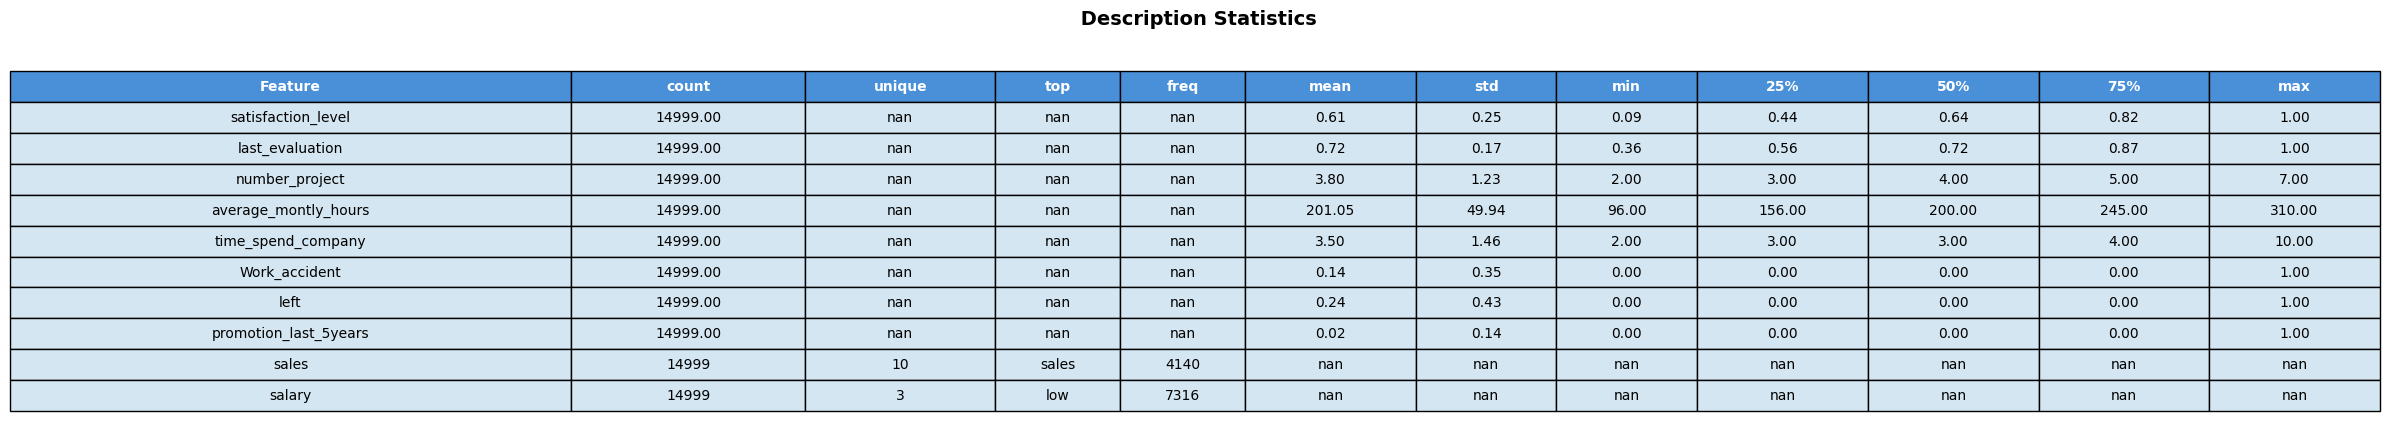

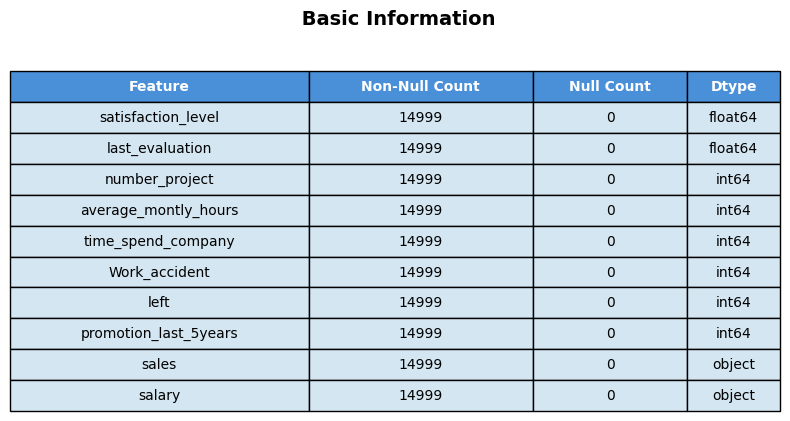

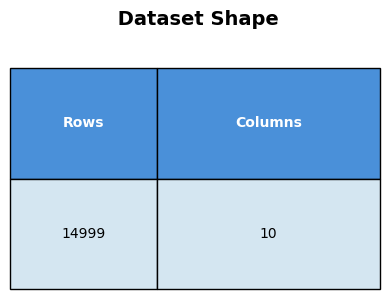




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



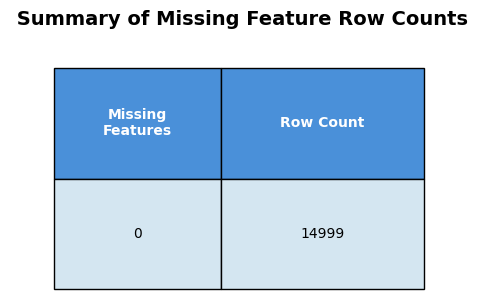

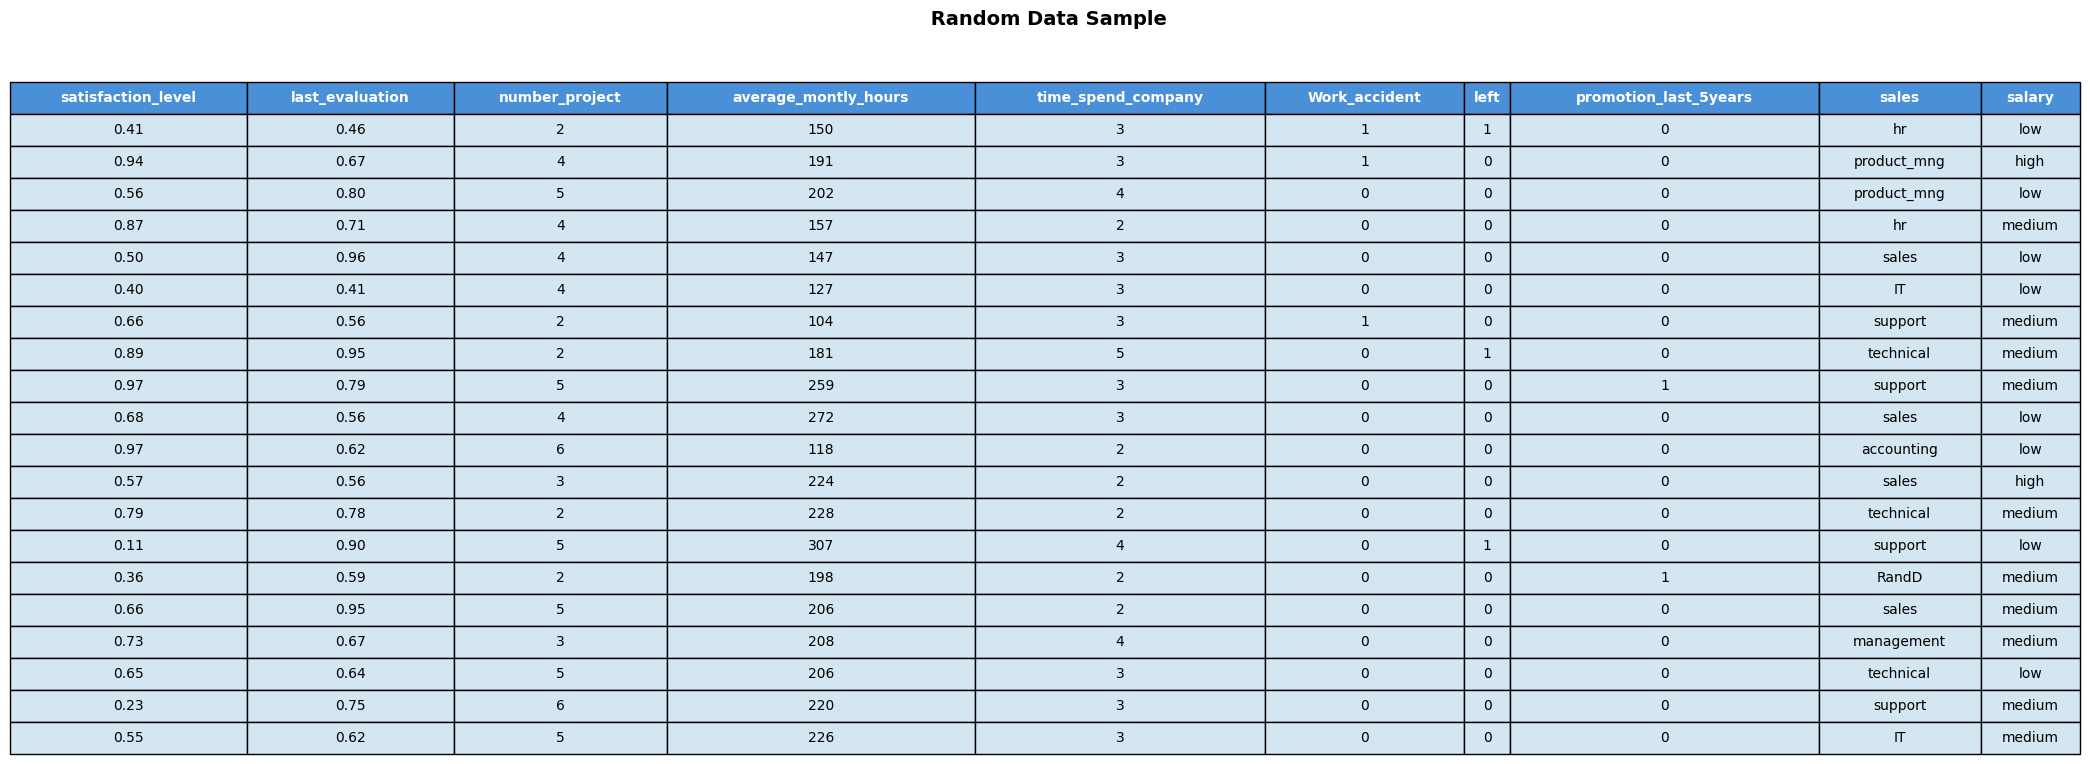

In [466]:
# print out the dataframes stats
print(data_set_name)
PrintDataFrameStatistics(df_employeeTurnOver)

### **Initial EDA Analysis** ###
    - Movie Data - 14999 rows of data, 10 features (columns)
    - No rows of missing or (nan) data in either dataset
    - Need to leading/following trim() categorical feature columns

## **2. Initial Data Wrangling** ## 

### **Missing Values and Imputation** ###
Not required

##### **Trim Categorical Features** #####

In [467]:
obj_cols = df_employeeTurnOver.select_dtypes(include='object').columns
df_employeeTurnOver[obj_cols] = df_employeeTurnOver[obj_cols].apply(lambda col: col.str.strip())

#### **Feature Column Renaming** ####
    - Rename 'sales' to 'department' 
      'sales' column is in correctly named. It really should be called department as the column includes such
      values as: sales, accounting, hr,.. 
    - Rename average_montly_hours (sp mistake)

In [468]:
df_employeeTurnOver.rename(columns={'sales': 'department'}, inplace=True)
df_employeeTurnOver.rename(columns={'average_montly_hours': 'average_monthly_hours'}, inplace=True)

# Save dataframe so get_dummies() technique can be applied later
df_employeeTurnOverSaved = df_employeeTurnOver.copy (deep=True)

Unique number_project Values


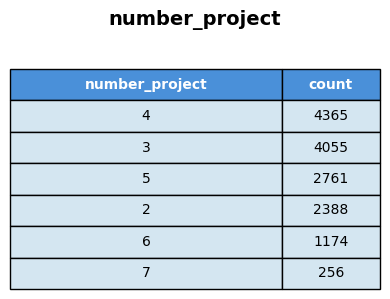



Unique average_monthly_hours Values


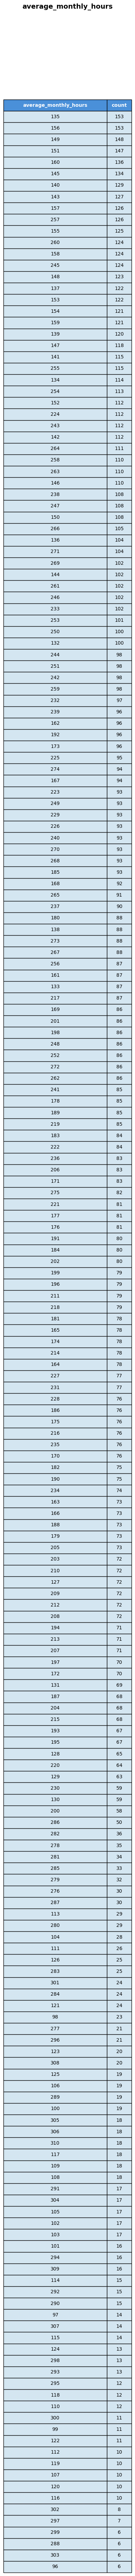



Unique time_spend_company Values


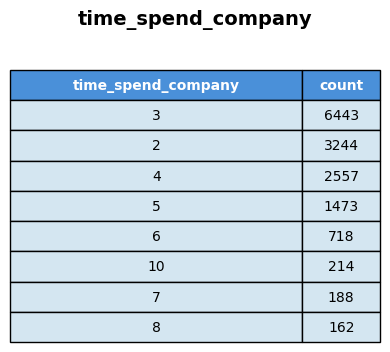



Unique Work_accident Values


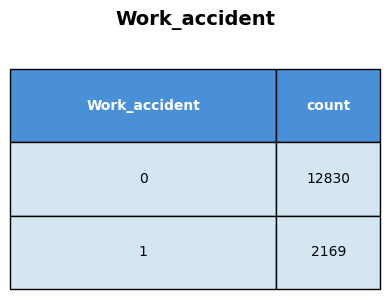



Unique left Values


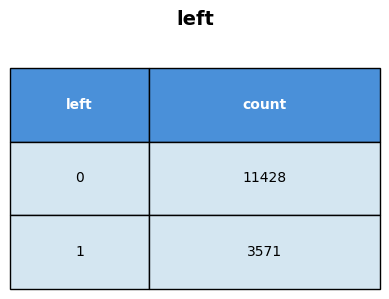



Unique promotion_last_5years Values


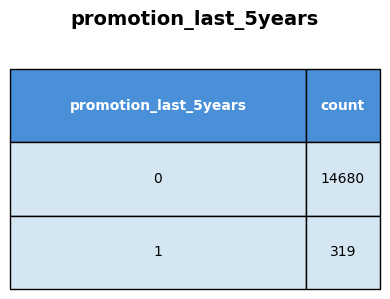



Unique department Values


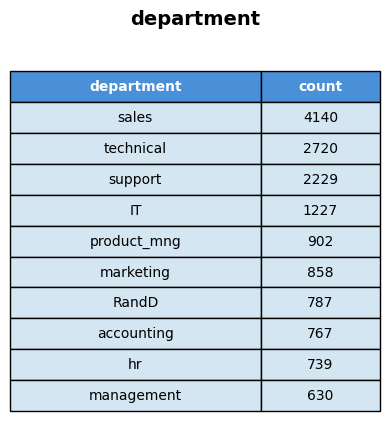



Unique salary Values


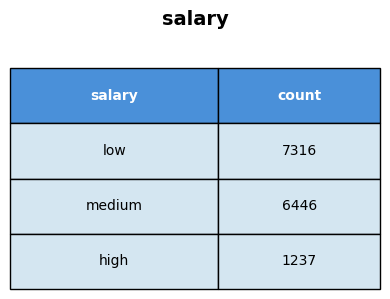

In [469]:
def DisplayUniqueValues(feature_name):
    print(f'Unique {feature_name} Values')
    df_departments = df_employeeTurnOver[feature_name].value_counts().reset_index()
    DisplayTable(df_departments, table_title=feature_name)    

feature_names = ['number_project', 'average_monthly_hours',
                'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'department', 'salary']

list(map(DisplayUniqueValues, feature_names))
print()


#### **Label Encoding - One-Hot Encode Categorical Features** ####

***********************************
Description Stats
***********************************

                   Feature    count unique    top  freq        mean  \
0       satisfaction_level  14999.0    NaN    NaN   NaN    0.612834   
1          last_evaluation  14999.0    NaN    NaN   NaN    0.716102   
2           number_project  14999.0    NaN    NaN   NaN    3.803054   
3    average_monthly_hours  14999.0    NaN    NaN   NaN  201.050337   
4       time_spend_company  14999.0    NaN    NaN   NaN    3.498233   
5            Work_accident  14999.0    NaN    NaN   NaN     0.14461   
6                     left  14999.0    NaN    NaN   NaN    0.238083   
7    promotion_last_5years  14999.0    NaN    NaN   NaN    0.021268   
8               department    14999     10  sales  4140         NaN   
9                   salary    14999      3    low  7316         NaN   
10           department_IT  14999.0    NaN    NaN   NaN    0.081805   
11        department_RandD  14999.0    NaN    NaN   NaN  

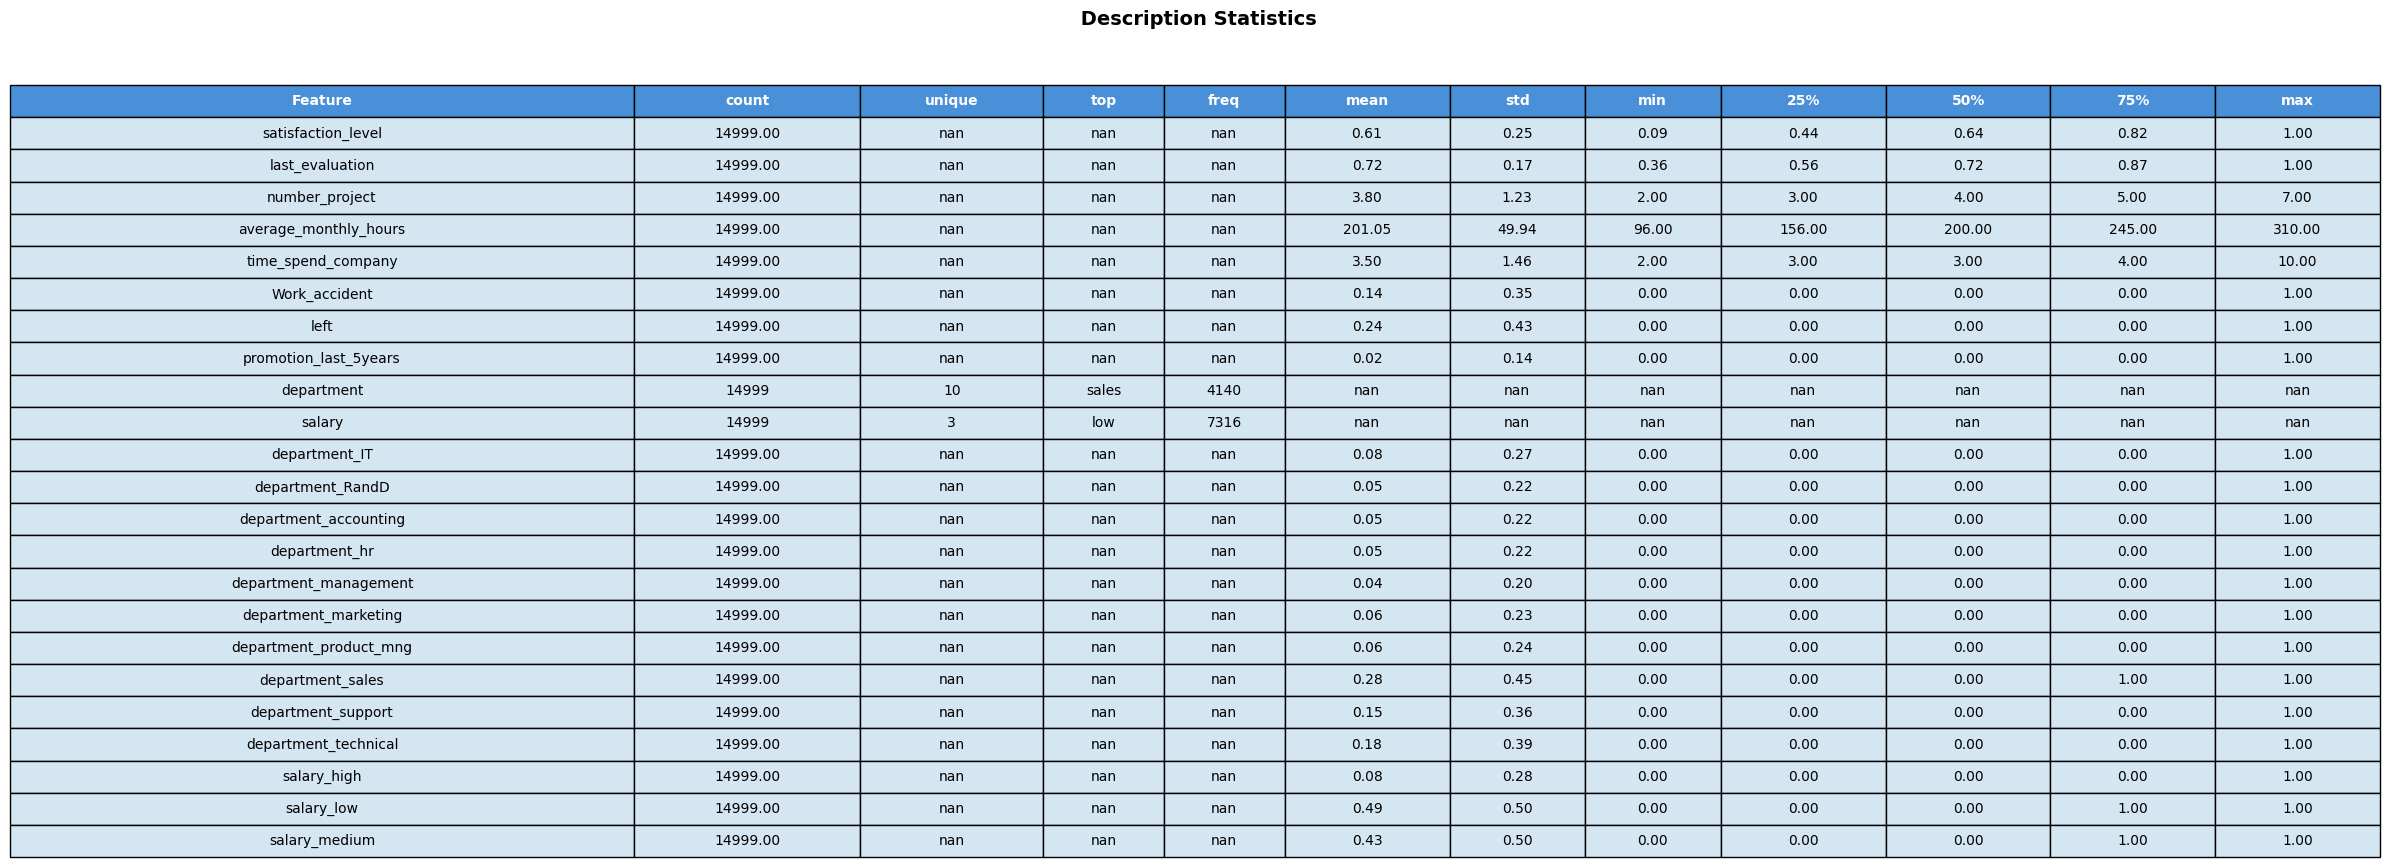

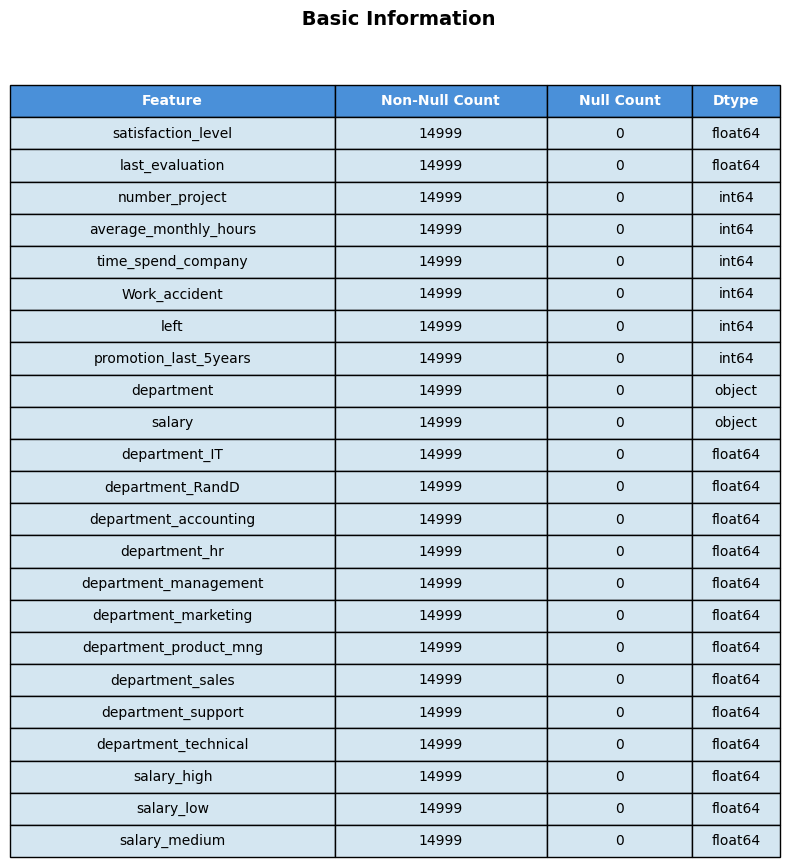

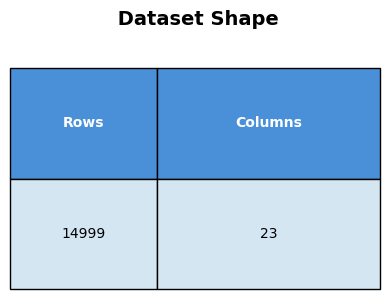




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



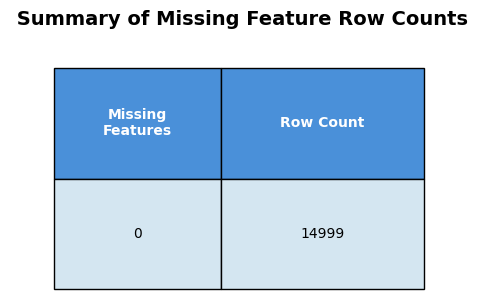

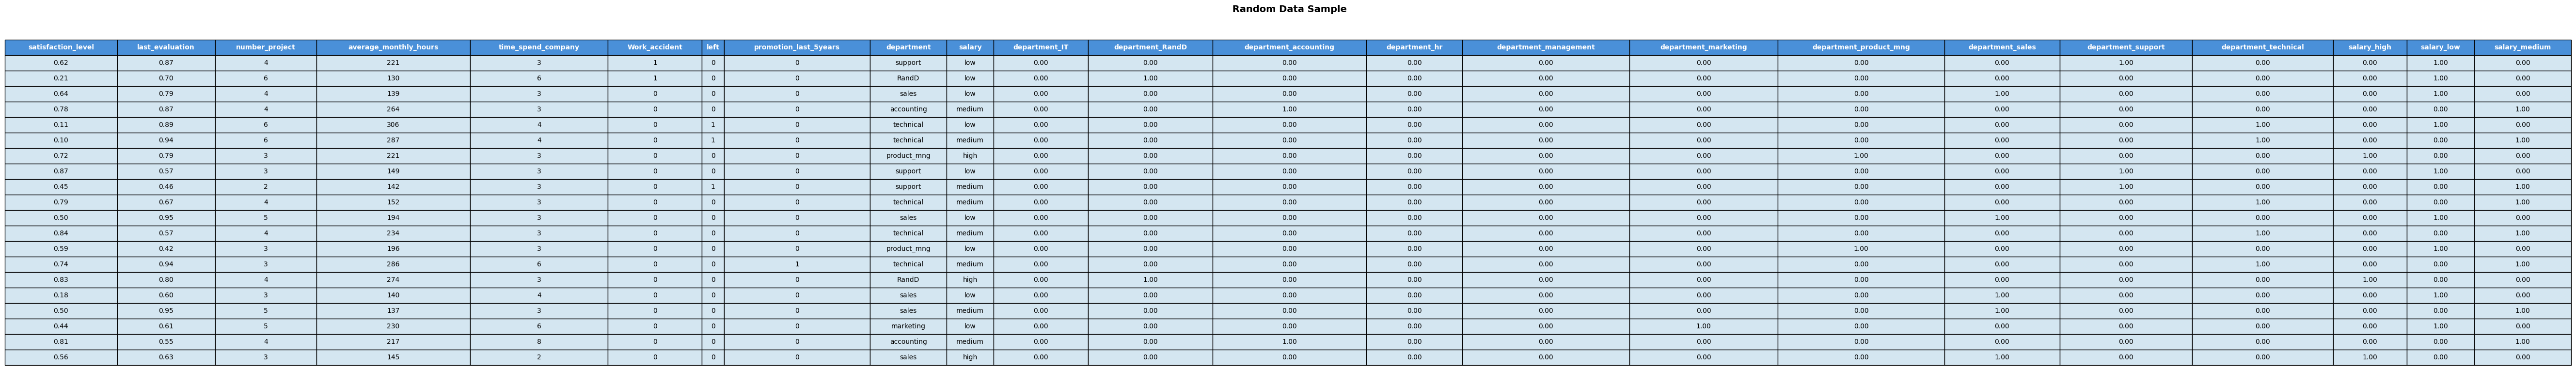

In [470]:
# Use the nominal categorical variable (department)
# Apply one-hot encoding
#encoder = OneHotEncoder(sparse_output=False, drop='first')

# Don't drop 'first' for now as we want to see all our columns and the distribution
# Drop these later depanding on the model we use to reduce/avoid multicolinearity
encoder = OneHotEncoder(sparse_output=False)

# Convert Department
onehot_array = encoder.fit_transform(df_employeeTurnOver[['department']])

# Create dataframe with proper column names
df_onehot = pd.DataFrame(
    onehot_array,
    columns=encoder.get_feature_names_out(['department']),
    index=df_employeeTurnOver.index
)

# Join back to original and drop original column
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_onehot], axis=1)

# Convert Salary
onehot_array = encoder.fit_transform(df_employeeTurnOver[['salary']])

# Create dataframe with proper column names
df_onehot = pd.DataFrame(
    onehot_array,
    columns=encoder.get_feature_names_out(['salary']),
    index=df_employeeTurnOver.index
)

# Join back to original and drop original column
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_onehot], axis=1)

PrintDataFrameStatistics(df_employeeTurnOver)

### **Data Type Conversion** ###
    - For OS memory performance and model efficiency, convert to more efficient data types.

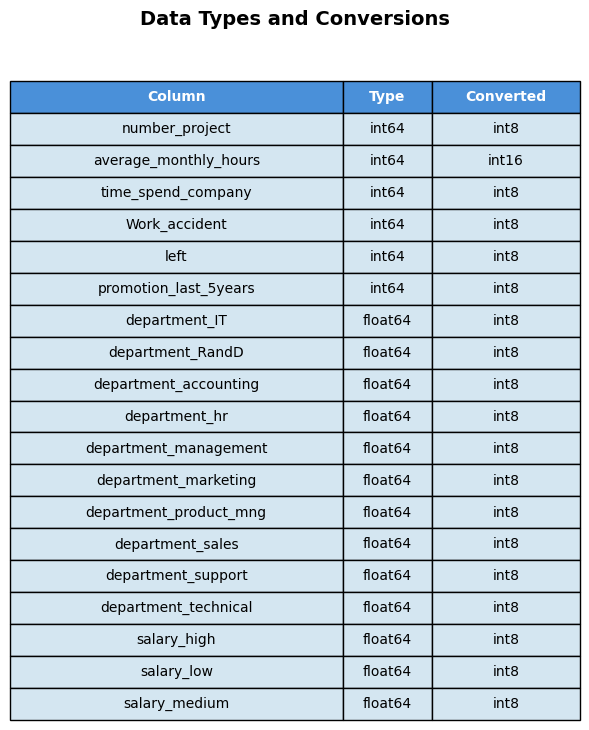




Converted Data Columns


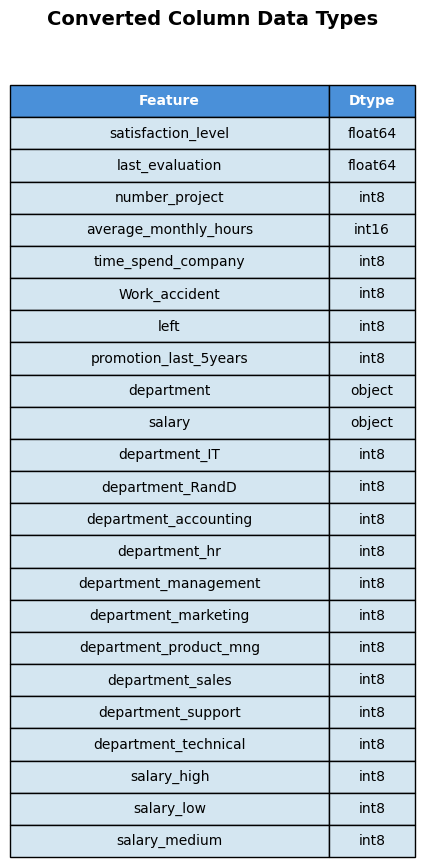

In [471]:
# Features, Types and Data Type Conversion Targets..
df_types = pd.DataFrame({
                    'Column': [
                        'number_project', 'average_monthly_hours', 'time_spend_company', 'Work_accident', 'left',
                        'promotion_last_5years', 'department_IT', 'department_RandD', 'department_accounting',
                        'department_hr', 'department_management', 'department_marketing', 'department_product_mng',
                        'department_sales', 'department_support', 'department_technical', 'salary_high', 'salary_low',
                        'salary_medium',
                    ],
                    'Type': [
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'float64', 
                        'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 
                        'float64', 'float64', 'float64', 'float64', 'float64', 'float64',
                    ],
                    'Converted': [
                        'int8', 'int16', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8'
                    ]
                })


#print(df_types)

DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)
print()

def PerformDataConversion(df_target, remove_class_prefix=False, display_output=False):

    # Convert Int64 to Int16 
    int_columns = ['average_monthly_hours']
    df_target[int_columns] = df_target[int_columns].astype('int16')

    # Convert Int64 to Int8 
    int_columns = ['number_project', 'time_spend_company', 'Work_accident', 'left',
                    'promotion_last_5years', 'department_IT', 'department_RandD', 'department_accounting',
                    'department_hr', 'department_management', 'department_marketing', 'department_product_mng',
                    'department_sales', 'department_support', 'department_technical', 'salary_high', 'salary_low',
                    'salary_medium' 
                ]
    
    if remove_class_prefix == True:
        int_columns = [col.replace('department_', '').replace('salary_', '') for col in int_columns]

    df_target[int_columns] = df_target[int_columns].astype('int8')

    if display_output == True:
        print('Converted Data Columns')

        df_info = pd.DataFrame({
                                'Feature': df_target.columns,
                                'Dtype': df_target.dtypes.values
                                }).reset_index(drop=True)
        DisplayTable(df_info, 'Converted Column Data Types')
    
    return df_target

df_Merged = PerformDataConversion(df_employeeTurnOver, display_output=True)

## <u>**3. Detailed Exploratory Data Analysis**</u> ##
##### **Display Count Plots** #####
    Display some initial Bar/Count Plots to give us an insight into any trends such as:
        - What days, months, years ratings were likely to occur
        - What movie release years the data set is focusing on 

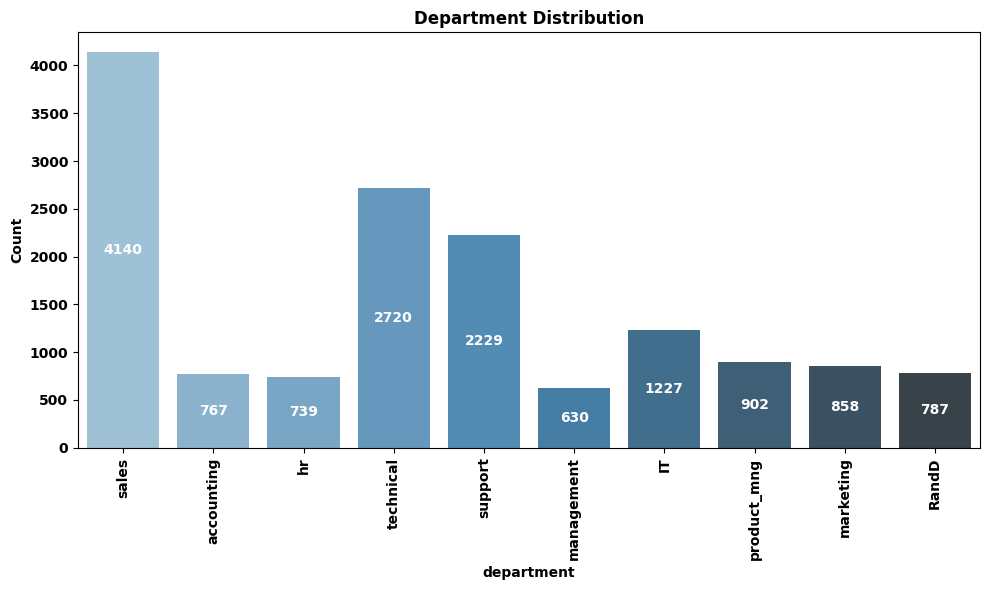

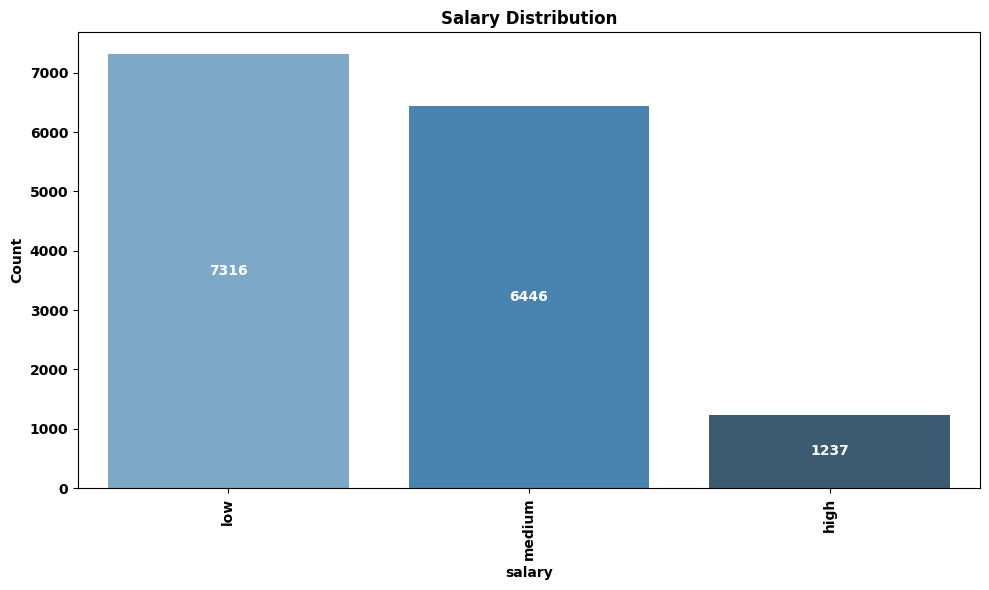

In [472]:
def DisplayBarPlot(df_Target, x_axis, y_axis, plot_title):
    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=x_axis, 
                     y=y_axis, 
                     data=df_Target, 
                     hue=x_axis, 
                     palette='Blues_d', 
                     legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel('Genre', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, hue_value=None, plot_labels=None, displayLabels=True):

    if hue_value is not None:
        hue = hue_value
    else:
        hue = x_axis

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=hue, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    if plot_labels is not None:
        plt.legend(title=hue, labels=plot_labels)

    plt.tight_layout()
    plt.show()


# Department Count Plot
departmentOrder = df_employeeTurnOver['department'].unique().tolist()
DisplayCountPlot(df_employeeTurnOver, 'department', departmentOrder, 'Department Distribution', (10,6))

departmentOrder = df_employeeTurnOver['salary'].unique().tolist()
DisplayCountPlot(df_employeeTurnOver, 'salary', departmentOrder, 'Salary Distribution', (10,6))

##### **Examine Numerical Feature Distributions** #####

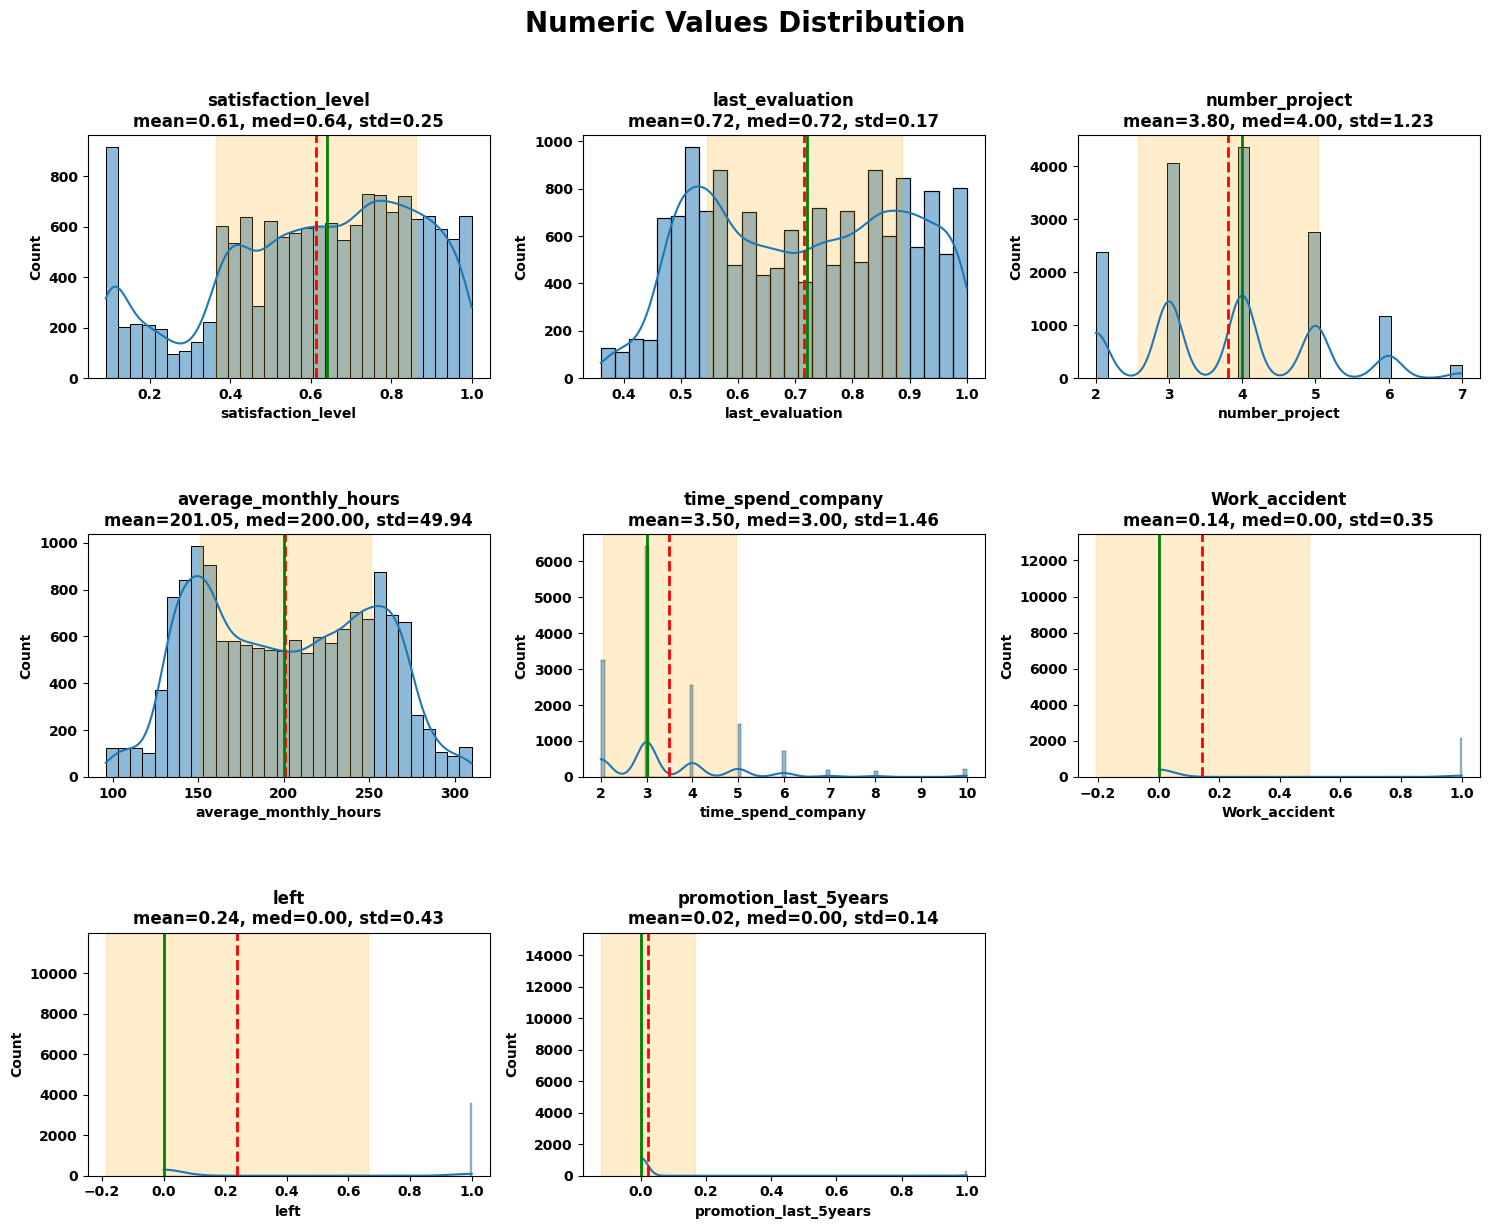

In [473]:
def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(title, y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

feature_columns = [
                    'satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours',
                    'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years'
                ]
DisplayNumericFeatureHistograms(df_employeeTurnOver, 
                                feature_columns=feature_columns,
                                plot_title = 'Numeric Values Distribution', 
                                display_statistics=True)

##### **Numerical Feature Distribution Observations** #####
    - satisfaction_level is normalish
    - last_evaluation is normalish/bimodal with 2 definite peaks
    - number_project looks multi modal but actually, when you look close it has a normal distribution
    - average_monthly_hours is normalish/bimodal with 2 definite peaks
    - The following features look like they have a definite right skew:
        - time_spend_company
        - Work_accident
        - left
        - promotion_last_5years

##### **Correlation Matrix of Numerical Features** #####

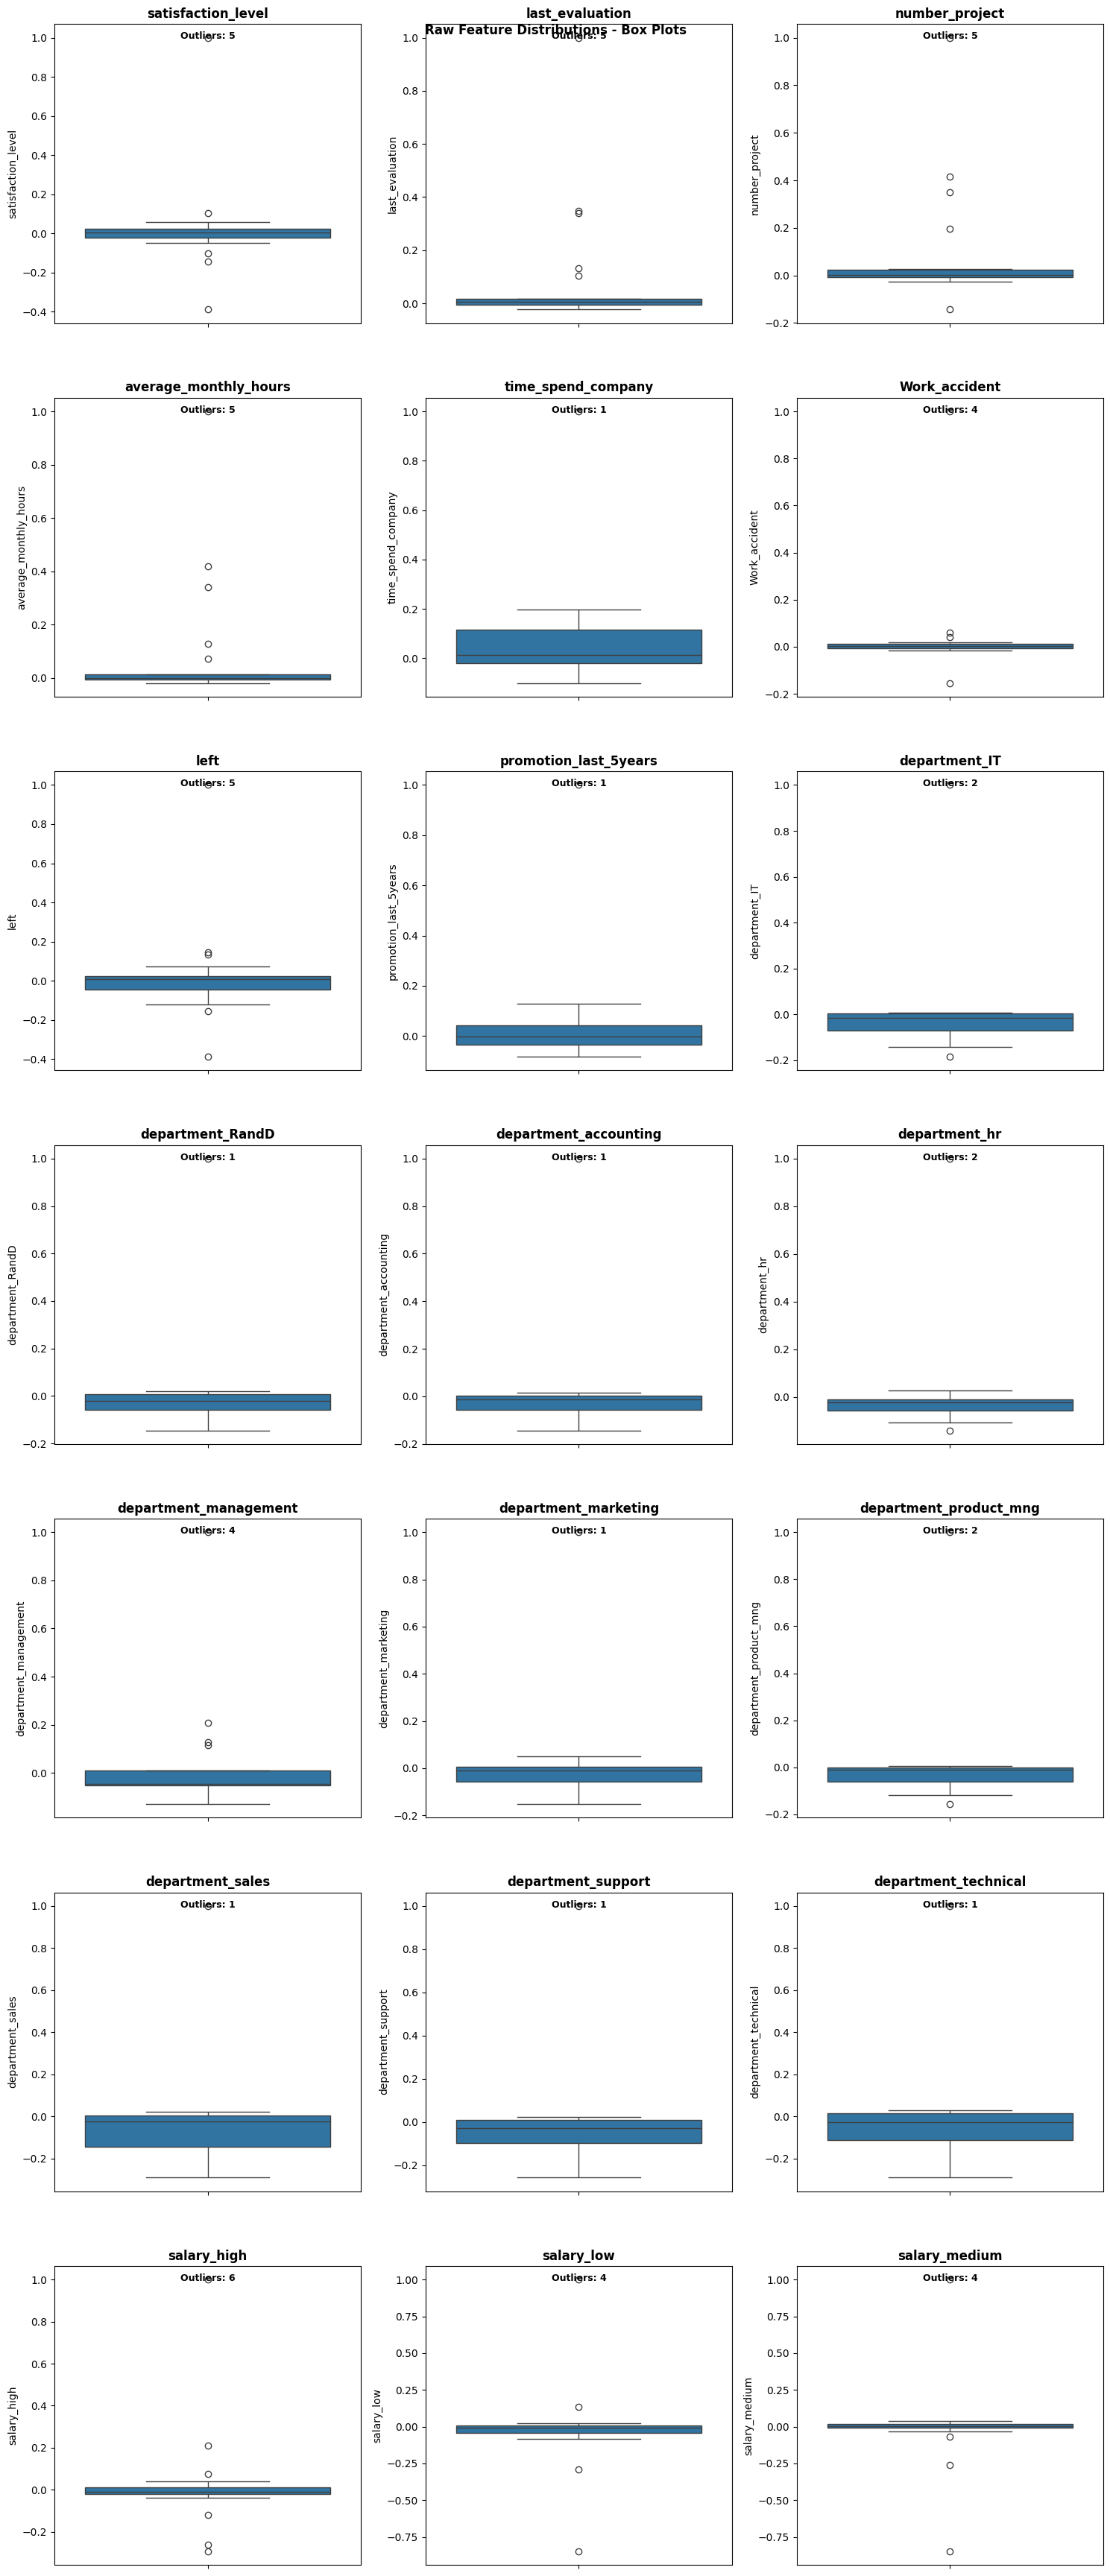

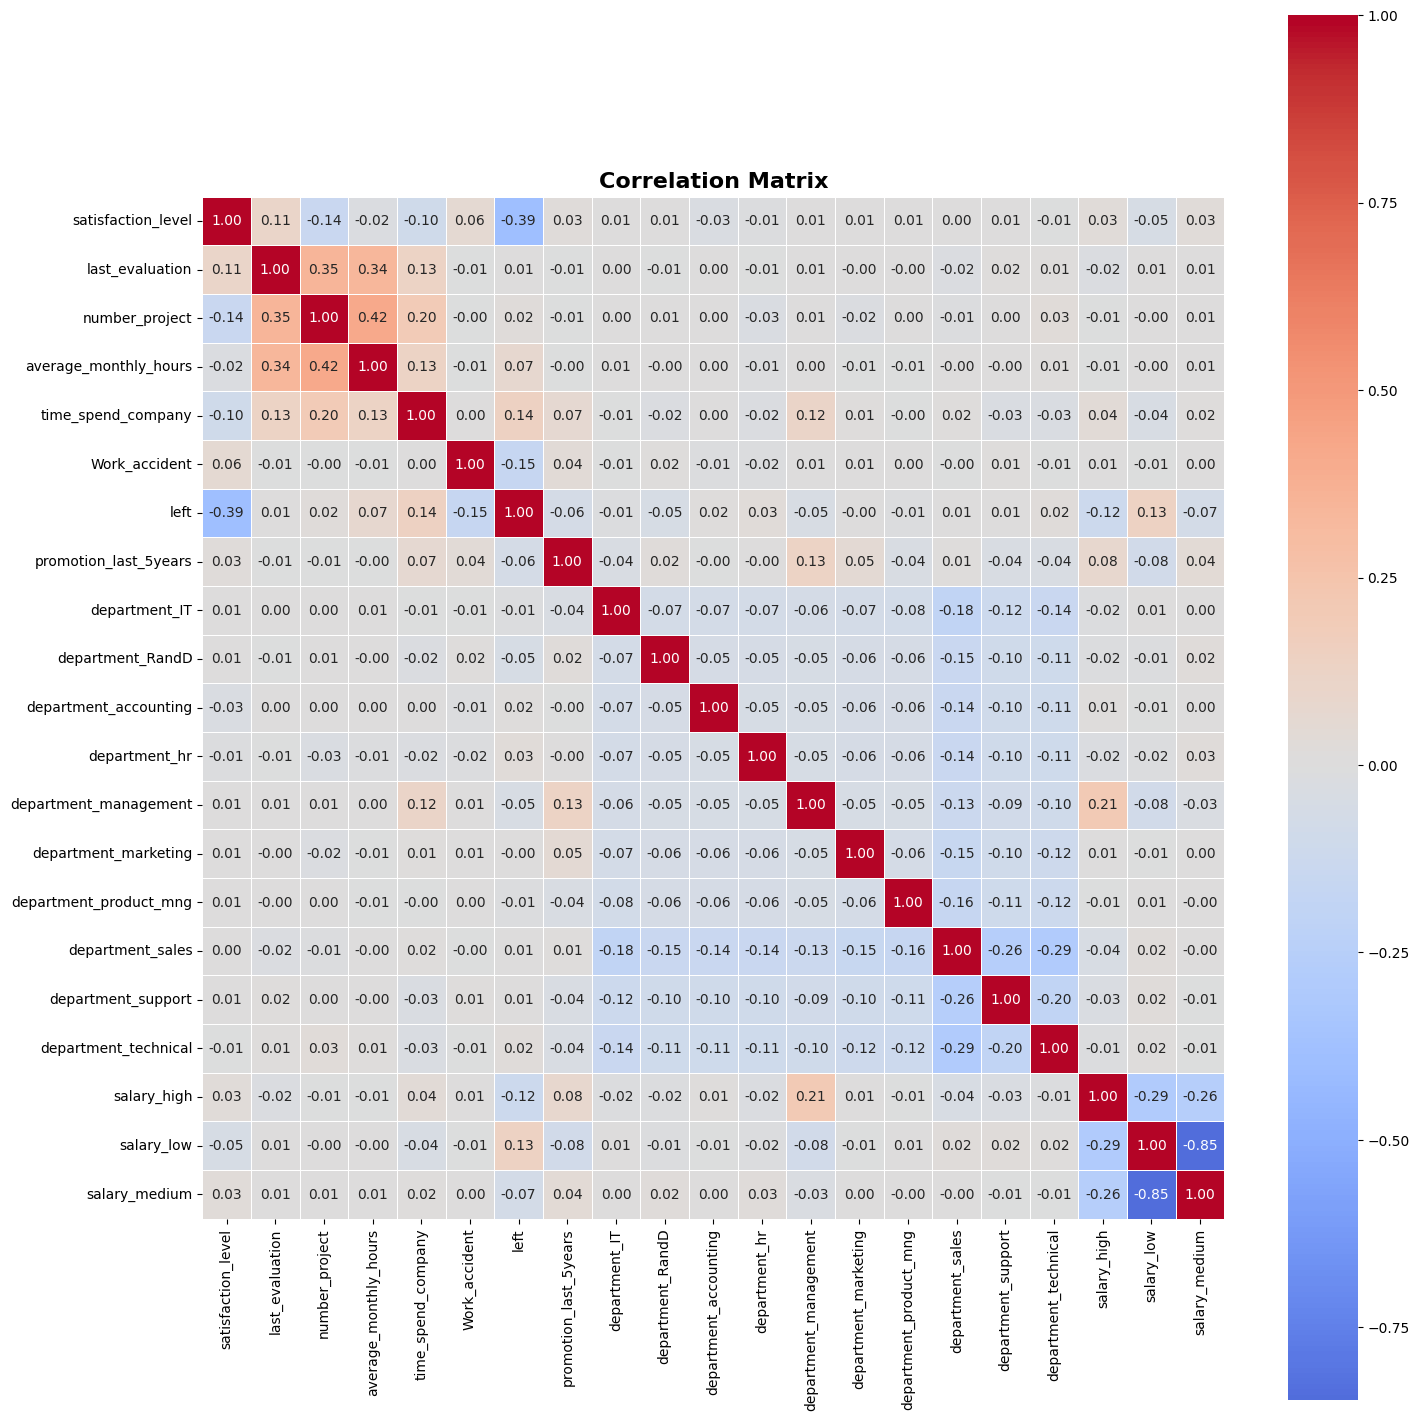

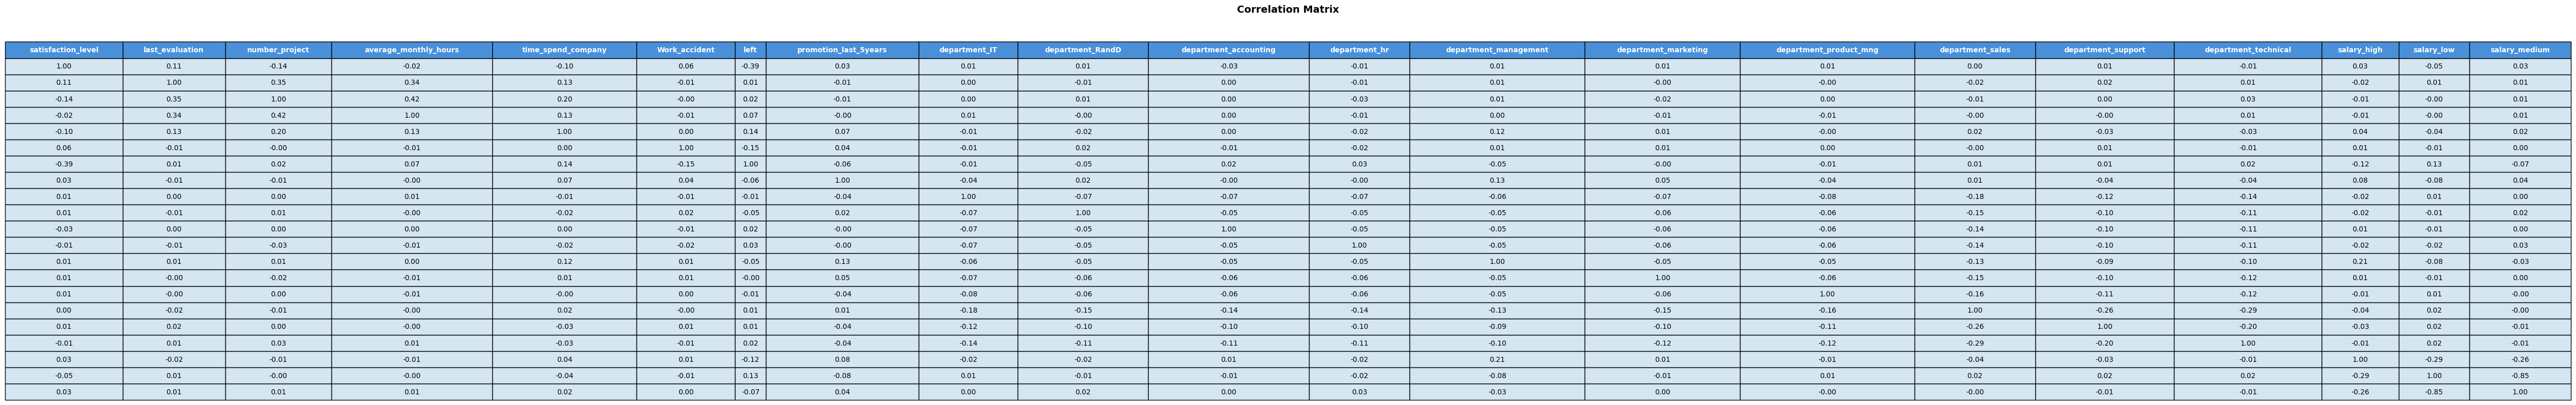



The following table displays the lowest correlations in the dataset, having abs(value) of close to 0.00


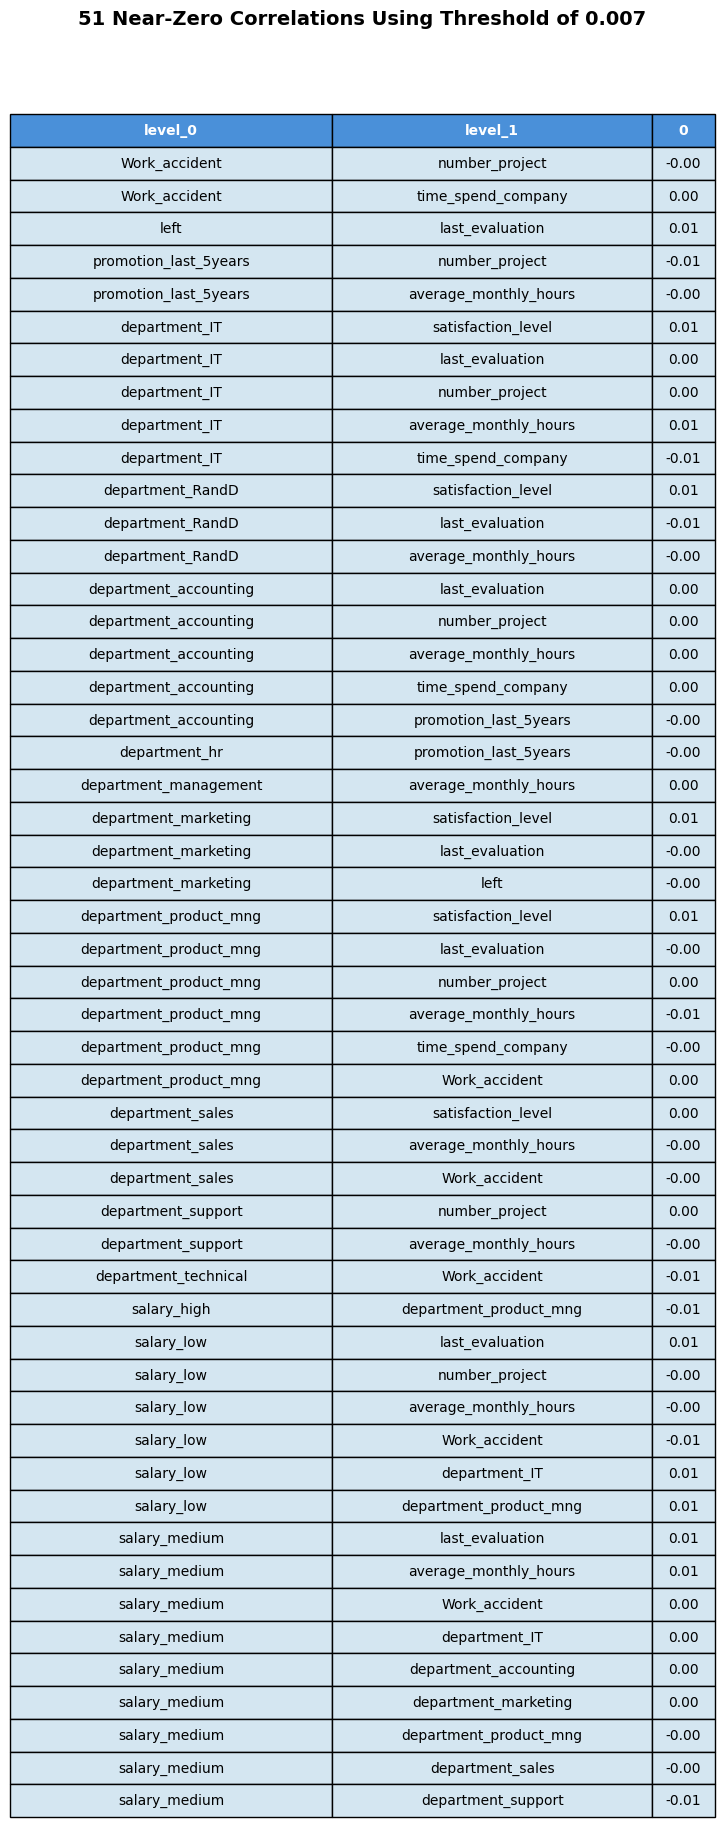

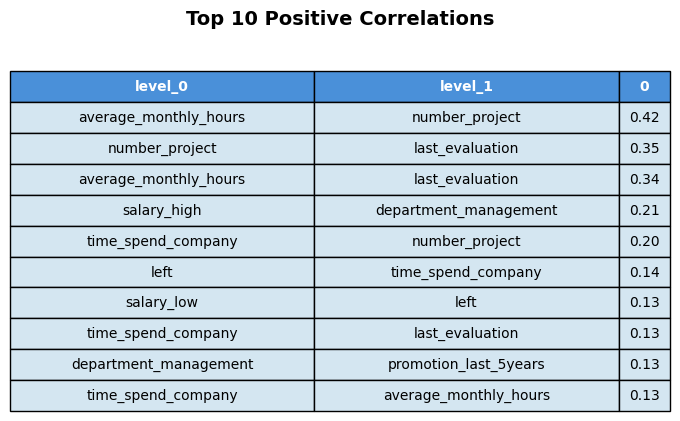

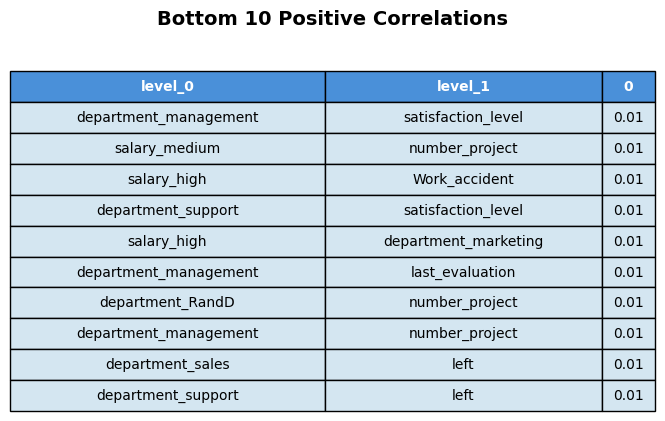



                 level_0               level_1         0
0  department_management    satisfaction_level  0.007172
1          salary_medium        number_project  0.007377
2            salary_high         Work_accident  0.009040
3     department_support    satisfaction_level  0.009185
4            salary_high  department_marketing  0.009642
5  department_management       last_evaluation  0.009662
6       department_RandD        number_project  0.009703
7  department_management        number_project  0.009728
8       department_sales                  left  0.009923
9     department_support                  left  0.010700



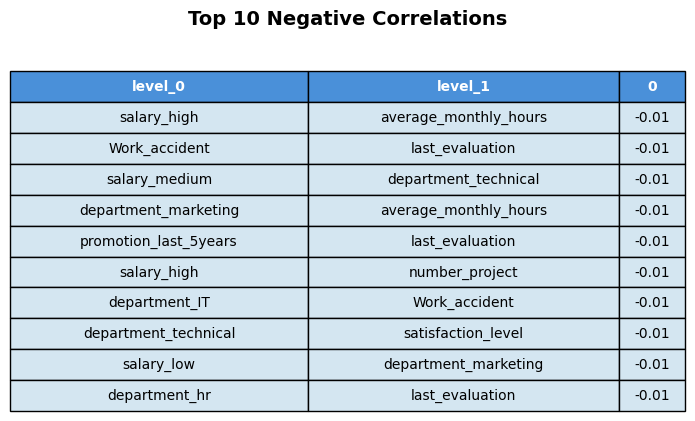

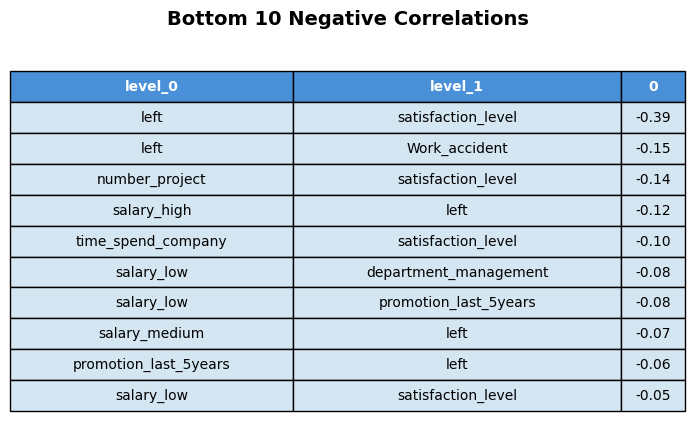

In [474]:
#
# Features to Bike Rentals Correlations
#
def PlotBoxPlotsToViewDistributions(df_target):

    columns = df_target.select_dtypes(include='number').columns.tolist()
    n_cols = len(columns)

    fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=3, figsize=(15, 5 * ((n_cols + 2) // 3)))
    axes = axes.flatten()

    plt.suptitle('Raw Feature Distributions - Box Plots', fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(columns):
        sns.boxplot(data=df_target, y=col, ax=axes[i])    
        axes[i].set_title(col, fontweight='bold')

        # Optional: Add count of outliers
        Q1 = df_target[col].quantile(0.25)
        Q3 = df_target[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = len(df_target[(df_target[col] < lower) | 
                                            (df_target[col] > upper)])
        axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 


def DisplayCorrelationMatrixPlots(df_correlationInfo):
        
        # print(type(df_correlationInfo))
        # print(df_correlationInfo)

        # Create heatmap
        plt.figure(figsize=(15, 15))
        sns.heatmap(df_correlationInfo, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, linewidths=0.5)
        plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print()
        print()    


# Check if two features are from the same one-hot encoded group
def SameOneHotEncodedGroup(feat1, feat2):
    
    prefixes = ['department_', 'salary_']

    for prefix in prefixes:
        if feat1.startswith(prefix) and feat2.startswith(prefix):
            return True
        
    return False        
        

def DisplayFeatureCorrelationInfo(df_target, display_correlation_matrix=True, display_box_plots=True, display_table=True):
    
    df_correlationMatrix = df_target.corr(numeric_only=True)
    #print(f'Correlation Matrix Type: {type(df_correlationInfo)}')
    # print(df_correlationInfo)

    if display_box_plots == True:
       PlotBoxPlotsToViewDistributions(df_correlationMatrix)

    if display_correlation_matrix == True:
        DisplayCorrelationMatrixPlots(df_correlationMatrix)

    if display_table == True:
         DisplayTable(df_correlationMatrix, table_title='Correlation Matrix')

    # Get top 10 for each category:
    #
    # 1) Highest positive covariance
    # 2) Lowest positive covariance
    # 3) Lowest negative covariance
    # 4) Highest negative covariance

    # Unstack to series for sorting
    # To prevent from duplicate (feature order swapped) entries, focus on upper triangle of matrix
    # Numpy has function to do this.
    # Get upper triangle only (no duplicates, no diagonal)
    mask = np.triu(np.ones(df_correlationMatrix.shape), k=1).astype(bool)
    correlationSeries = df_correlationMatrix.where(mask).unstack().dropna()

    # Filter out same-group pairs
    # (Definitely needed help figgering this one out....)
    correlationSeries = correlationSeries[
                                            ~correlationSeries.index.map(lambda x: SameOneHotEncodedGroup(x[0], x[1]))
                                        ]

    # Drop self referencing (val == 1)
    correlationSeries = correlationSeries[correlationSeries != 1.0]

    # No absolute 0 in float/double values ..., have to use threshold
    threshold = 0.007
    noCorrelationSeries = correlationSeries[abs(correlationSeries) < threshold]
    df_zeroCorrelations = noCorrelationSeries.reset_index()
    print('The following table displays the lowest correlations in the dataset, having abs(value) of close to 0.00')
    DisplayTable(df_zeroCorrelations, table_title=f'{len(df_zeroCorrelations)} Near-Zero Correlations Using Threshold of {threshold}')

    # Filter out near-zero values before getting top/bottom
    correlationSeries = correlationSeries[abs(correlationSeries) >= threshold]

    # Positive Correlations
    positiveCorrelations = correlationSeries[correlationSeries > 0]
    df_topPositiveCorrelations = positiveCorrelations.sort_values(ascending=False).head(10).reset_index()
    df_bottomPositiveCorrelations = positiveCorrelations.sort_values(ascending=True).head(10).reset_index()

    # Negative Correlations
    negativeCorrelations = correlationSeries[correlationSeries < 0]
    df_topNegativeCorrelations = negativeCorrelations.sort_values(ascending=False).head(10).reset_index()
    df_bottomNegativeCorrelations = negativeCorrelations.sort_values(ascending=True).head(10).reset_index()

    # Display results in pretty table
    DisplayTable(df_topPositiveCorrelations, table_title='Top 10 Positive Correlations')
    #print(df_topPositiveCorrelations)
    print()

    DisplayTable(df_bottomPositiveCorrelations, table_title='Bottom 10 Positive Correlations')
    print(df_bottomPositiveCorrelations)
    print()

    DisplayTable(df_topNegativeCorrelations, table_title='Top 10 Negative Correlations')
    #print(df_topNegativeCorrelations)
    print()

    DisplayTable(df_bottomNegativeCorrelations, table_title='Bottom 10 Negative Correlations')
    #print(df_bottomNegativeCorrelations)
    print()
    

DisplayFeatureCorrelationInfo(df_employeeTurnOver.drop(['department', 'salary'], axis=1))

#### **Observations from Correlation Matrix** ####
These observations exclude those correlations closest to 0.00 via threshold filtering.</br>
These 102 relationships have already been indentified has having the least/weakest association.</br>
</br>
It's difficult to interpret the correlations with the results including the noise of the one-hot-encoded </br>
categorical values being compared against each other (department_#### vs department_####, salary_#### vs salary_####). </br>
This distorts the results. In order to remove this noise, these relationships had to be removed from our series comparisons </br>

##### **Top Positive Covariances** #####
1. average_monthly_hours vs number_project (0.417211)
	- Makes sense. More projects, more hours.</br>
2. number_project vs last_evaluation (0.349333)
	- Strong correlation between the number of projects being worked on and strength of evaluation</br>
3. average_monthly_hours vs last_evaluation (0.339742)
	- Same for this, evaluation results tied to number of hours worked.</br>
4. salary_high vs department_management (0.209077)
	- Moderate correlation between high salaries and management positions</br>
5. time_spend_company vs number_project (0.196786)
	- Moderate between number of projects and years at a company</br>
6. left vs time_spend_company (0.144822)
	- Moderate correlation between number of years at a company and leaving</br>
7. salary_low vs left (0.134722)
	- Moderate for low salary and leaving company.</br>
8. time_spend_company vs last_evaluation (0.131591)
	- Moderate between years at company and value of last evaluation</br>
9. department_management vs promotion_last_5years (0.128087)
	- Low-moderate correlation between management position and frequency of promotions</br>
10. time_spend_company vs average_monthly_hours (0.12775)
	- Low-moderate for years at company vs monthly hours</br>

##### **Bottom Positive Covariances** #####
1. department_management vs satisfaction_level (0.007172)
	- Being a manager doesn't affect satisfaction level</br>
2. salary_medium vs number_project (0.007377)
	- Salary not related to number of projects being worked on. (You're giving them free hours!!)</br>
3. department_sales vs left (0.009923)
	- Being in sales doesn't make you more likely to leave</br>

##### **Top Negative Covariances** #####
1. salary_high vs average_monthly_hours (-0.007101)
	- Salary not related to hours worked.</br>
2. Work_accident vs last_evaluation (-0.007104)
	- Accidents don't affect reviews</br>
3. salary_medium vs department_technical (-0.007673)
	- Salary level not correlated with technical positions</br>
##### **Bottom Negative Covariances** #####
1. left vs satisfaction_level (-0.388375)
	- Job satisfaction affects wheter people will leave.</br>
2. left vs Work_accident (-0.154622)
	- If someone's had a work accident, they're moderately more likely to leave.</br>
3. number_project vs satisfaction_level (-0.142970)
	- Employees with less projects are more satisfied. More projects, stress increases, unhappier employee.</br>
4. salary_high vs left (-0.120929)
	- Higher salaried employees are moderately more likely to see employment elsewhere.</br>

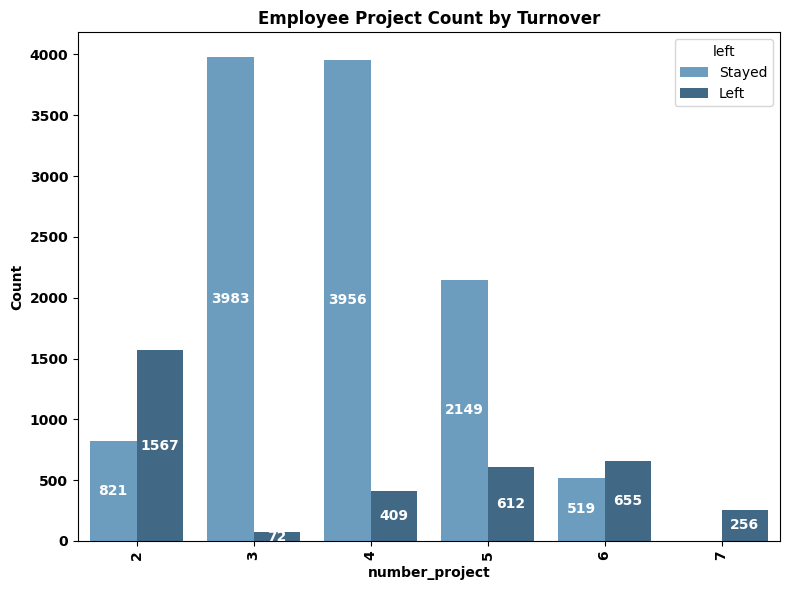

In [475]:
# Department Count Plot
projectNumberOrder = np.sort(df_employeeTurnOver['number_project'].unique().tolist())
DisplayCountPlot(df_employeeTurnOver, 
                 'number_project', 
                 projectNumberOrder, 
                 'Employee Project Count by Turnover', 
                 (8,6), 
                 hue_value='left',
                 plot_labels=['Stayed','Left'])

##### **Employee Project Count Turnover Analysis** #####
People working on 3 to 4 projects are likely to stay (that's the sweet spot)</br>
</br>
After that, as then number of projects increase, so does the likelyhood that they will leave.</br>
This is probably due to any of the following reasons (increased stress, not being able to focus and get better</br>
on specific tasks/skillsets, not feeling appreciated for efforts?)</br>
Once someone is assigned 7 projects, they are out the door</br>
</br>
People assigned less than 3 projects are highly likely to leave (not feeling valued/respected/appreciated).</br>

## <u>**4. Cluster Analysis - Employee Turnover**</u> ##
Choose the following columns: </br>
        - satisfaction_level</br>
        - last_evaluation</br>
        - left</br>
</br>

For completeness and to satisfy my curiousity, I examined KMeans, Hierarchical and DBScan Clustering</br>
and plotted results fir KMeans and Hierarchical.

##### **Cluster Utility Functions** #####

In [476]:
def PlotClusterResults(k_range, wcss, sil_scores, cluster_type):

    #
    # Plot the Elbow Method
    #

    # I need a 1X2 plot to display 2 plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes = axes.flatten()

    axes[0].plot(k_range, wcss, 'b-', marker='o')

    kl = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
    print(f"Optimal k for KMeans Clustering: {kl.elbow}")
    axes[0].axvline(x=kl.elbow, color='r', linestyle='--', label=f'Elbow at k={kl.elbow}')

    axes[0].set_title('The Elbow Method')
    axes[0].set_xlabel('Number of clusters')
    axes[0].set_ylabel('WCSS')
    axes[0].legend()
    
    #
    # Plot Silhouette Analysis
    #
    best_k = k_range[np.argmax(sil_scores)]
    best_score = max(sil_scores)

    axes[1].plot(k_range, sil_scores, 'b-', marker='o')
    axes[1].axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
    axes[1].axhline(y=best_score, color='gray', linestyle=':', alpha=0.5)

    # Annotate each point
    for k, score in zip(k_range, sil_scores):
        axes[1].annotate(f'{score:.3f}', (k, score), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

    axes[1].set_xlabel('Number of clusters')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Analysis')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Clustering Analysis for {cluster_type}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout()
    plt.show()
    print()
    print()

##### **KMeans Clustering** #####

Optimal k for KMeans Clustering: 6


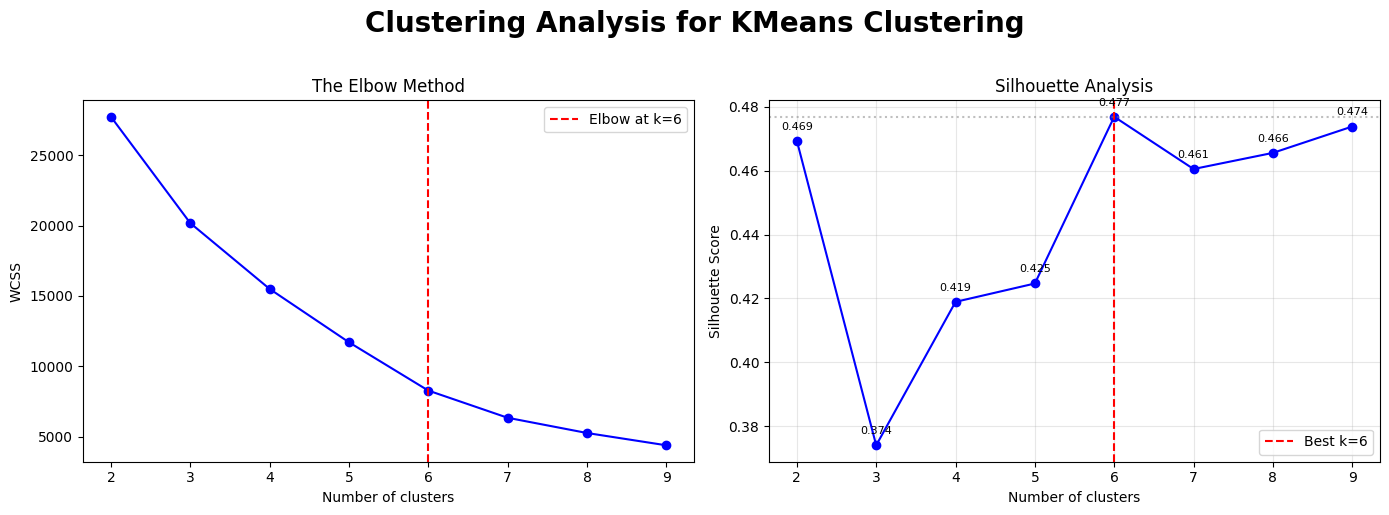

In [477]:
# KMeans Cluster Analysis

df_forScaling = df_employeeTurnOver[['satisfaction_level','last_evaluation','left']]
#print(df_forScaling.shape)

kmeans_wcss = []
kmeans_sil_scores = []
k_range = range(2, 10) 

# Scale data before applying kmeans
scaler = StandardScaler()

# Create a dataframe from scale (which returns npdarray)
df_employeeTurnOverScaled = pd.DataFrame(
                                        scaler.fit_transform(df_forScaling),
                                        columns=df_forScaling.columns,
                                        index=df_forScaling.index
                                    )

#
# KMeans Clustering
# 

# Iterate through K-Means cluster with number of clusters 2-10
for i in k_range:
    model = KMeans(n_clusters = i, n_init=10, init = 'k-means++', random_state = 315)
    model.fit(df_employeeTurnOverScaled)
    kmeans_wcss.append(model.inertia_)

    labels = model.predict(df_employeeTurnOverScaled)
    kmeans_sil_scores.append(silhouette_score(df_employeeTurnOverScaled, labels))

PlotClusterResults(k_range, kmeans_wcss, kmeans_sil_scores, 'KMeans Clustering')



##### **KMeans Results and Analysis** #####
Elbow method indicates 6 clusters is optimal</br>
Silhouette scores indicate that 6 clusters is optimal</br>
Both scoring methods agree on using 6 clusters.</br>

##### **Hierarchical (Agglomerative) Clustering** #####

Optimal k for KMeans Clustering: 5


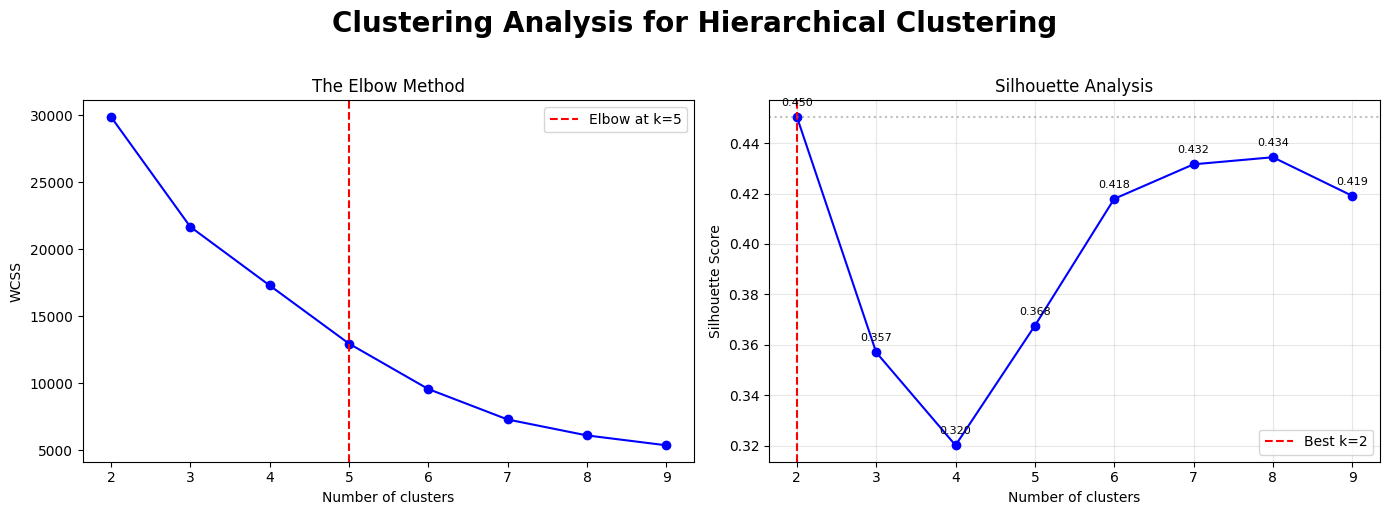

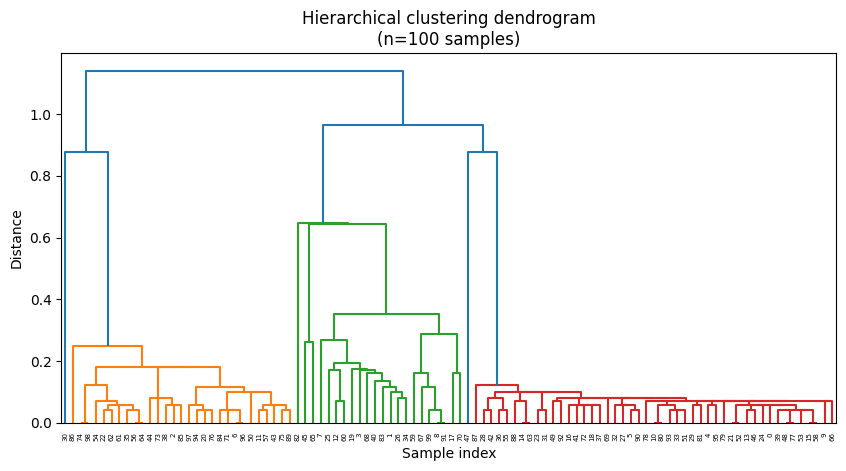

In [478]:
#
# Hierarchical (Agglomerative) Clustering
#
agglo_sil_scores = []
agglo_wcss = []

# Iterate through K-Means cluster with number of clusters 2-10
for i in k_range:
    # Fit hierarchical clustering
    model = AgglomerativeClustering(n_clusters=i)
    labels = model.fit_predict(df_employeeTurnOverScaled)

    # Calculate WCSS manually
    wcss = 0
    for cluster in range(i):
        labels = model.fit_predict(df_employeeTurnOverScaled)
        cluster_points = df_employeeTurnOverScaled[labels == cluster]
        centroid = cluster_points.mean(axis=0)
        wcss += ((cluster_points - centroid) ** 2).sum().sum()

    agglo_wcss.append(wcss)
    agglo_sil_scores.append(silhouette_score(df_employeeTurnOverScaled, labels))

PlotClusterResults(k_range, agglo_wcss, agglo_sil_scores, 'Hierarchical Clustering')

# Create dendrogram
linkage_matrix = linkage(df_employeeTurnOverScaled.iloc[:100])

plt.figure(figsize=(10, 4.8))
dendrogram(linkage_matrix)
plt.title('Hierarchical clustering dendrogram\n(n=100 samples)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


##### **Hierarchical Clustering Results and Analysis** #####
Processing for this analysis takes a long time (~5 min), </br>
Probably best to do this against a smaller subset of the dataframe. </br>
</br>
Elbow method indicates 5 clusters is optimal</br>
Silhouette scores indicate that 2 clusters is optimal</br>

##### **DBScan Clustering** #####

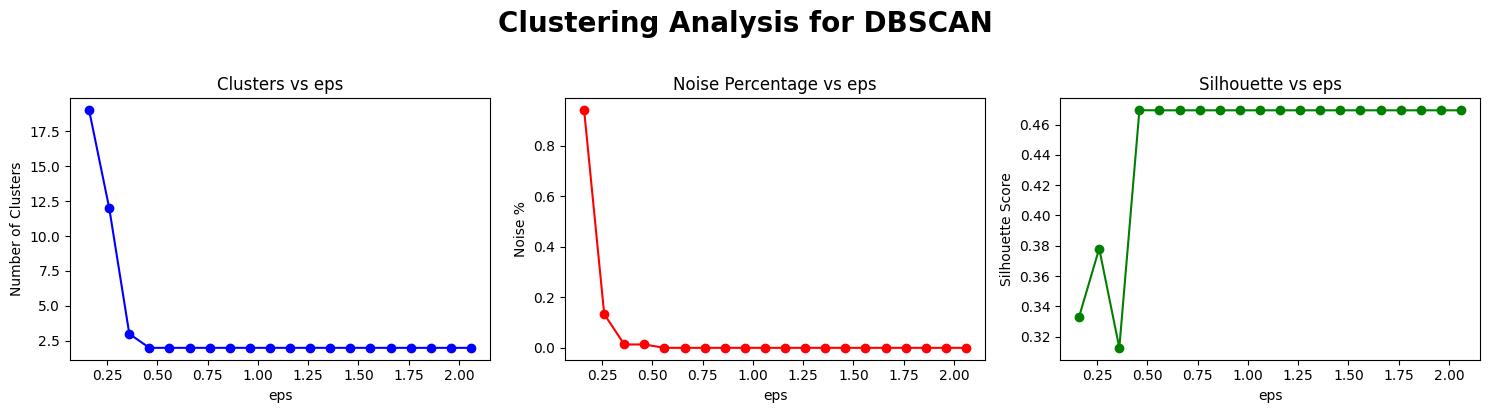

In [479]:
#
# DBSCAN Clustering
#

# Parameter ranges to test
eps_range = np.arange(0.16, 2.1, 0.1)  # Adjust based on your data
min_samples = 5  # Can also loop over this

dbscan_results = []

for eps in eps_range:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(df_employeeTurnOverScaled)
    
    # Count clusters (excluding noise labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Silhouette score (only if more than 1 cluster and not all noise)
    if n_clusters > 1 and n_noise < len(labels):
        # Exclude noise points for silhouette
        mask = labels != -1
        sil_score = silhouette_score(df_employeeTurnOverScaled[mask], labels[mask])
    else:
        sil_score = -1  # Invalid
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': n_noise / len(labels) * 100,
        'silhouette': sil_score
    })

df_dbscan_results = pd.DataFrame(dbscan_results)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Number of clusters
axes[0].plot(df_dbscan_results['eps'], df_dbscan_results['n_clusters'], 'b-', marker='o')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Clusters vs eps')

# Plot 2: Noise percentage
axes[1].plot(df_dbscan_results['eps'], df_dbscan_results['noise_pct'], 'r-', marker='o')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Noise %')
axes[1].set_title('Noise Percentage vs eps')

# Plot 3: Silhouette score
valid = df_dbscan_results[df_dbscan_results['silhouette'] > -1]
axes[2].plot(valid['eps'], valid['silhouette'], 'g-', marker='o')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette vs eps')

plt.suptitle(f'Clustering Analysis for DBSCAN', y=1.02, fontsize=20, fontweight='bold')
plt.subplots_adjust(top=0.92)  

plt.tight_layout()
plt.show()    



##### **DBSCAN Results and Analysis** #####
**Clusters vs eps:** eps flattens at 2 clusters when eps ≥ 0.5 </br>
**Noise % vs eps:** Nose drops at eps=0.3, flattens near 0% at eps ≥ 0.5 </br>
**Silhouette vs eps:** Best score (~0.47) at eps ≥ 0.5</br>
**Conclusion:** Use 2 clusters, but for completeness we'll examine results for 2, 3 and 4 clusters </br>
</br>

##### **Visualize Clusters for KMeans** #####
6 Clusters seems like a large number. </br>
It could be difficult to interpret/delineate the results. </br>
What would the results look like with 4, 5 or 6 clusters?</br>
Let's see.

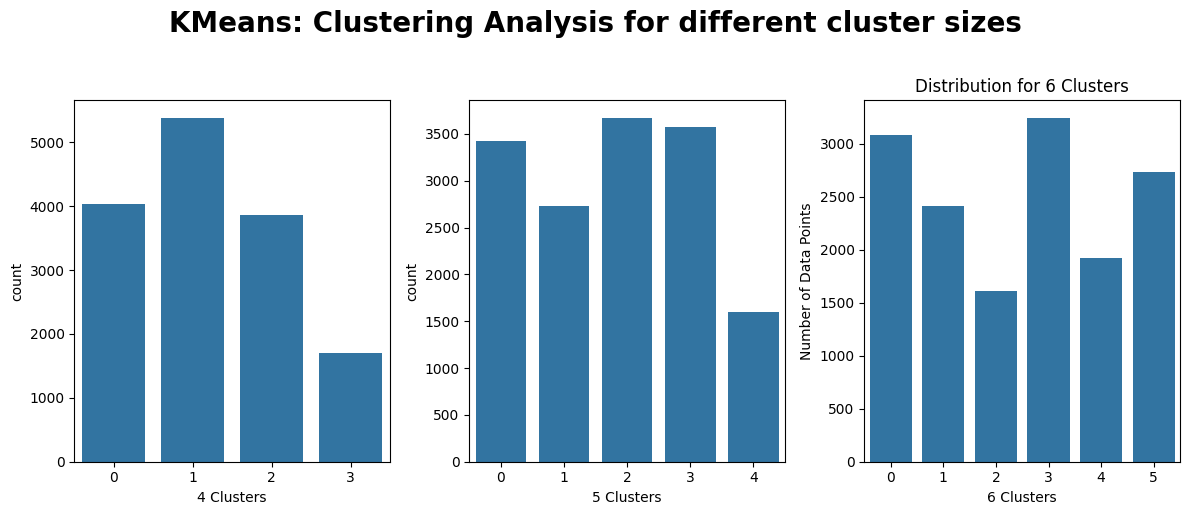

In [480]:
def DisplayCountPlotsForClusters(df_target, cluster_columns, plot_title):

    fig, axes = plt.subplots(1, len(cluster_columns), figsize=(12, 5))
    axes = axes.flatten()

    for i, col in enumerate(cluster_columns):

        sns.countplot(x=f'{col} Clusters', data=df_target, ax=axes[i])

        axes[2].set_xlabel(f'{col} Clusters')
        axes[2].set_ylabel('Number of Data Points')
        axes[2].set_title(f'Distribution for {col} Clusters')

    plt.suptitle(f'{plot_title}: Clustering Analysis for different cluster sizes', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout()
    plt.show()
    print()
    print()

features = ['satisfaction_level', 'last_evaluation']
clusterSizeColumns = [4, 5, 6]
df_kMeansClustering = df_employeeTurnOverScaled.copy(deep=True)

for k in [4, 5, 6]:
    model = KMeans(n_clusters=k, n_init=10, init='k-means++', random_state=315)
    df_kMeansClustering[f'{k} Clusters'] = model.fit_predict(
                                                                                df_kMeansClustering[features]
                                                                            )

DisplayCountPlotsForClusters(df_kMeansClustering, clusterSizeColumns, 'KMeans')


##### **Dimensionality Reduction Results for 4, 5 and 6 Clusters** #####
Since we've already reduced the dataset's features manually down to 3 features, </br>
there is no need for any addional dimensionality reduction.

##### **Plot KMeans Clustering for 4, 5 and 6 Nodes** #####

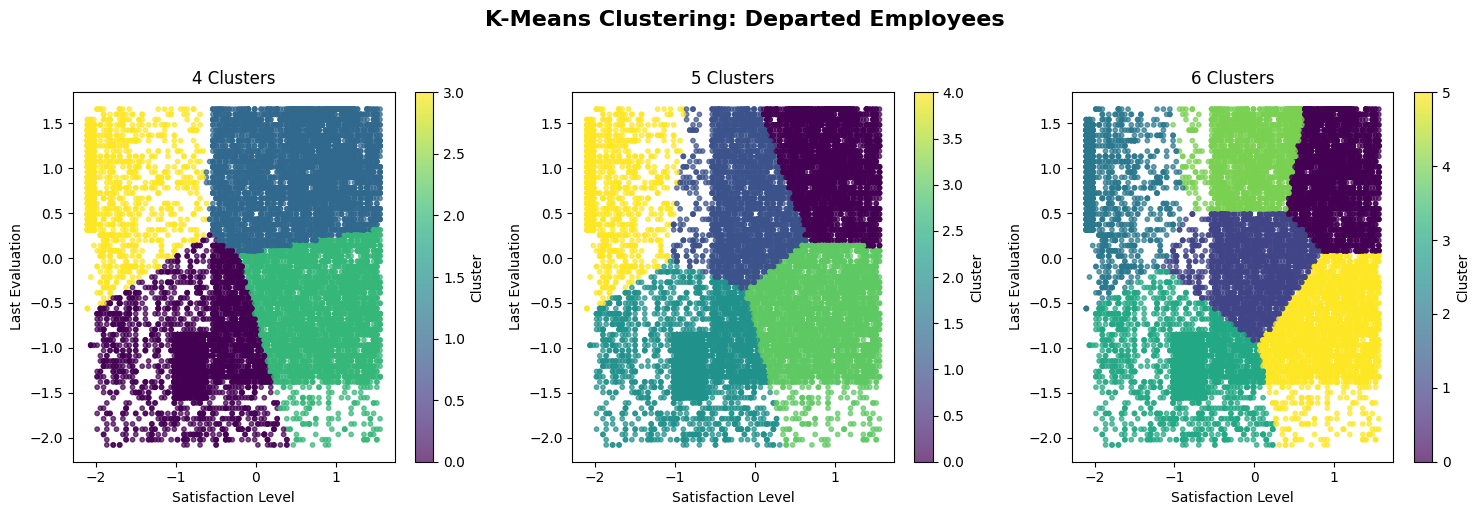

In [481]:
def DisplayScatterPlotsForClusters(df_target, cluster_columns, plot_title):

    fig, axes = plt.subplots(1, len(cluster_columns), figsize=(15, 5))

    for i, col in enumerate(cluster_columns):
        scatter = axes[i].scatter(
            df_target['satisfaction_level'], 
            df_target['last_evaluation'], 
            c=df_target[f'{col} Clusters'], 
            cmap='viridis', 
            s=10,
            alpha=0.7
        )
        axes[i].set_xlabel('Satisfaction Level')
        axes[i].set_ylabel('Last Evaluation')
        axes[i].set_title(f'{col} Clusters')
        plt.colorbar(scatter, ax=axes[i], label='Cluster')

    plt.suptitle(f'{plot_title} Clustering: Departed Employees', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

clusterColumns = ['4 Clusters', '5 Clusters', '6 Clusters']
DisplayScatterPlotsForClusters(df_kMeansClustering, clusterSizeColumns, 'K-Means')

#### **Plot KMeans Clustering Analysis** ####
##### **Optimal Number of Clusters** #####
The Elbow and Silhouette methods indicated that the optimal number of clusters for KMeans Clustering is 6.</br>
Despite that fact, examining the actual Scatter Plots, it appears that 4 Clusters gives the cleanest results.</br>
It offers the clearest delineation amongst the cluster groups with clear boundaries.</br>
There appear to be few, if any random points outside of the cluster regions </br>
</br>
##### **K-Means Scatter Plot Analysis** #####

#### **For Completeness, Plot results for Hierarchical and DBScan Clustering** ####
##### **Hierarchical Clustering** #####
Elbow method Optimal Clusters: 5</br>
Silhouette Scores Optimal Clusters: 2</br>
Plot 2, 3, 4, 5 Clusters (out of curiosity) </br>

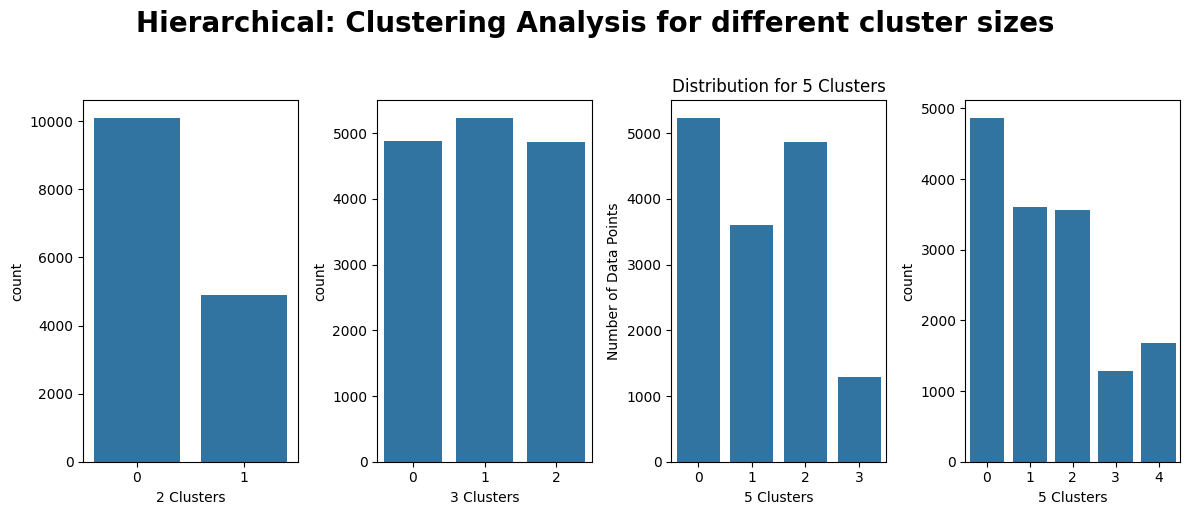

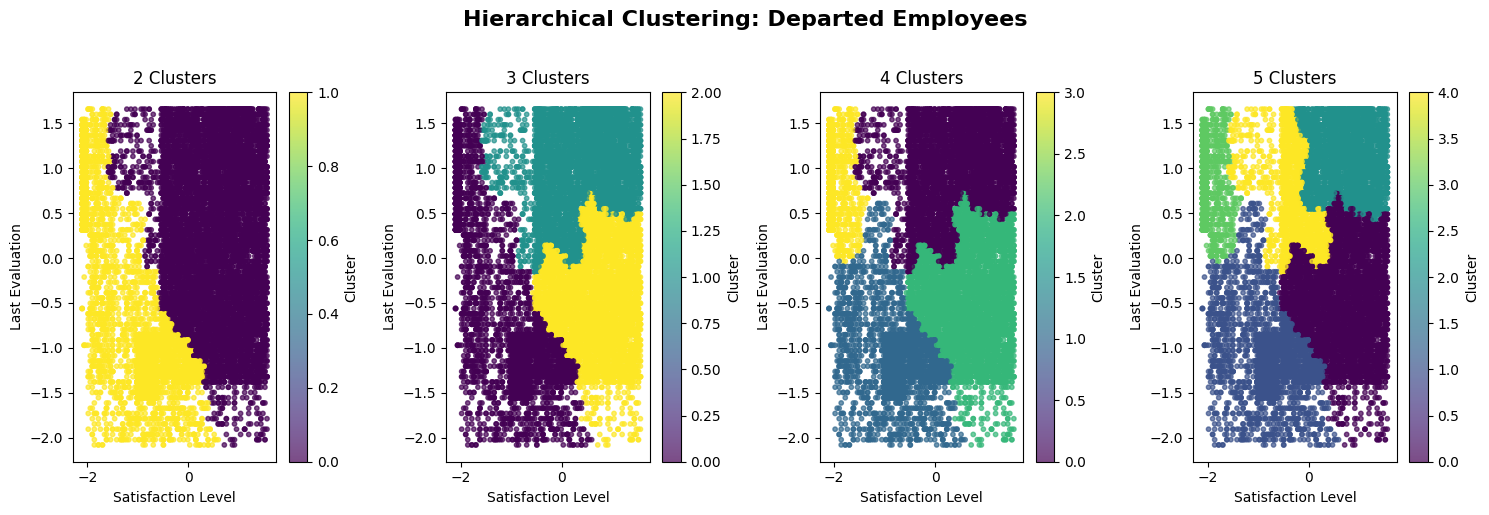

In [482]:
df_hierarchical = df_employeeTurnOverScaled.copy(deep=True)
clusterSizeColumns = [2, 3, 4, 5]

for k in clusterSizeColumns:
    model = AgglomerativeClustering(n_clusters=k)
    df_hierarchical[f'{k} Clusters'] = model.fit_predict(df_hierarchical[features])

DisplayCountPlotsForClusters(df_hierarchical, clusterSizeColumns, 'Hierarchical')
print()
DisplayScatterPlotsForClusters(df_hierarchical, clusterSizeColumns, 'Hierarchical')

##### **DBScan Clustering** #####
Elbow method Optimal Clusters: 5</br>
Silhouette Scores Optimal Clusters: 2</br>
Plot 2, 3, 4 Clusters (out of curiosity) </br>
**After several attempts** attempting to optimize the eps to produce the desired number of clusters,</br>
I was unable to figure it out - so I punted on the approach.</br>
The code remains in place to be revisited at a later date.


In [483]:
df_DBScan = df_employeeTurnOverScaled.copy(deep=True)
features = ['satisfaction_level', 'last_evaluation']

# Smaller eps values to get more clusters
eps_values = {
    '2 Clusters': 0.5,   
    '3 Clusters': 0.109,   
    '4 Clusters': 0.12,  
}

# Test to find actual cluster counts first
for label, eps in eps_values.items():
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(df_DBScan[features])
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = (labels == -1).sum()
    print(f"{label} (eps={eps}): actual clusters={n_clusters}, noise={noise_count}")

# Adjust eps values based on output above, then add to dataframe
for label, eps in eps_values.items():
    model = DBSCAN(eps=eps, min_samples=5)
    df_DBScan[label] = model.fit_predict(df_DBScan[features])

#DisplayCountPlotsForClusters(df_DBScan, [2, 3, 4], 'DBSCAN')

2 Clusters (eps=0.5): actual clusters=1, noise=0
3 Clusters (eps=0.109): actual clusters=9, noise=9
4 Clusters (eps=0.12): actual clusters=4, noise=5


## <u>**4. Handling Class Imbalances**</u> ##
##### **Convert categorical features to numeric using get_dummies()** #####

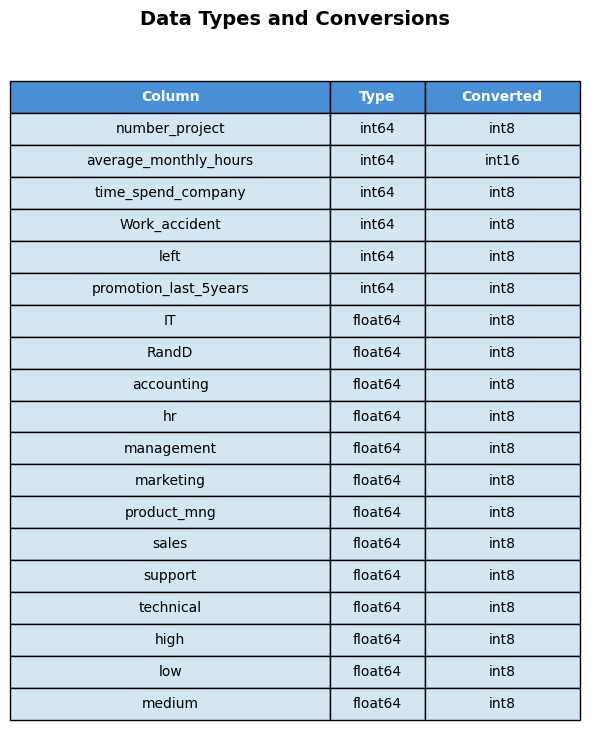



***********************************
Description Stats
***********************************

                  Feature    count        mean        std    min     25%  \
0      satisfaction_level  14999.0    0.612834   0.248631   0.09    0.44   
1         last_evaluation  14999.0    0.716102   0.171169   0.36    0.56   
2          number_project  14999.0    3.803054   1.232592   2.00    3.00   
3   average_monthly_hours  14999.0  201.050337  49.943099  96.00  156.00   
4      time_spend_company  14999.0    3.498233   1.460136   2.00    3.00   
5           Work_accident  14999.0    0.144610   0.351719   0.00    0.00   
6                    left  14999.0    0.238083   0.425924   0.00    0.00   
7   promotion_last_5years  14999.0    0.021268   0.144281   0.00    0.00   
8                      IT  14999.0    0.081805   0.274077   0.00    0.00   
9                   RandD  14999.0    0.052470   0.222981   0.00    0.00   
10             accounting  14999.0    0.051137   0.220284   0.00    0.0

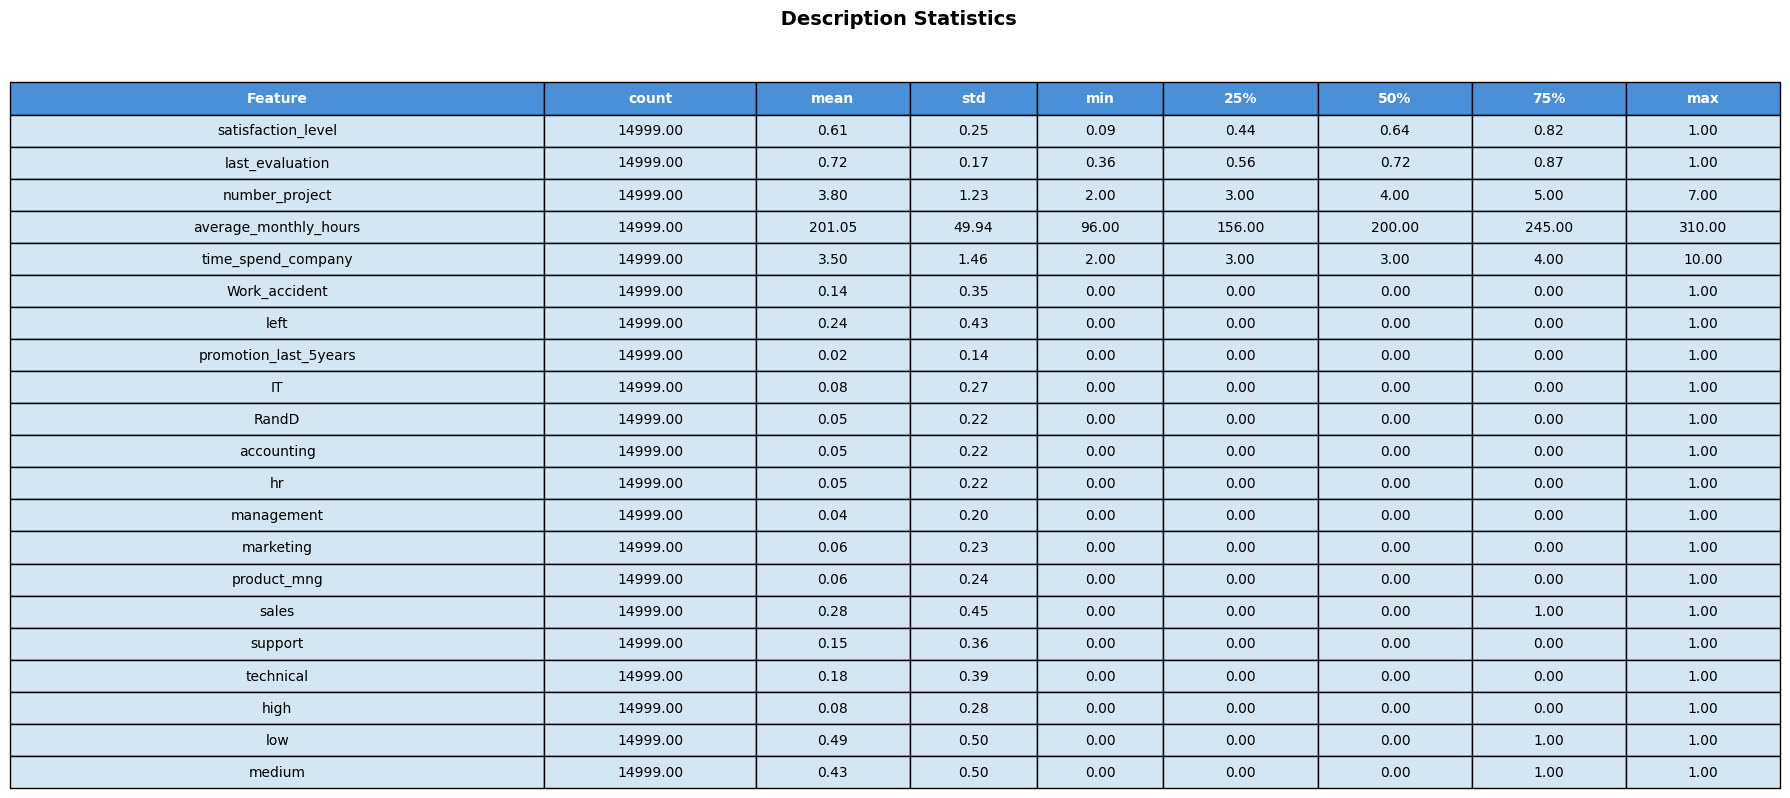

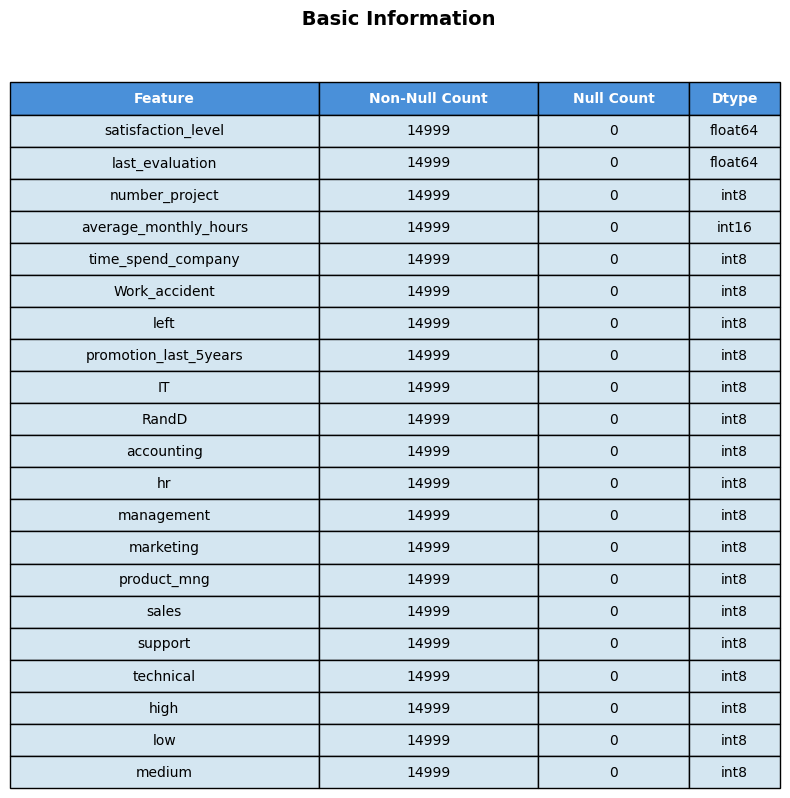

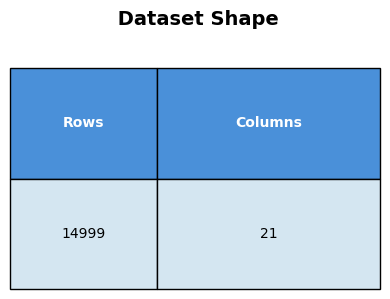




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



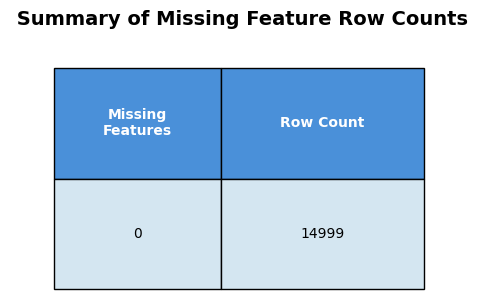

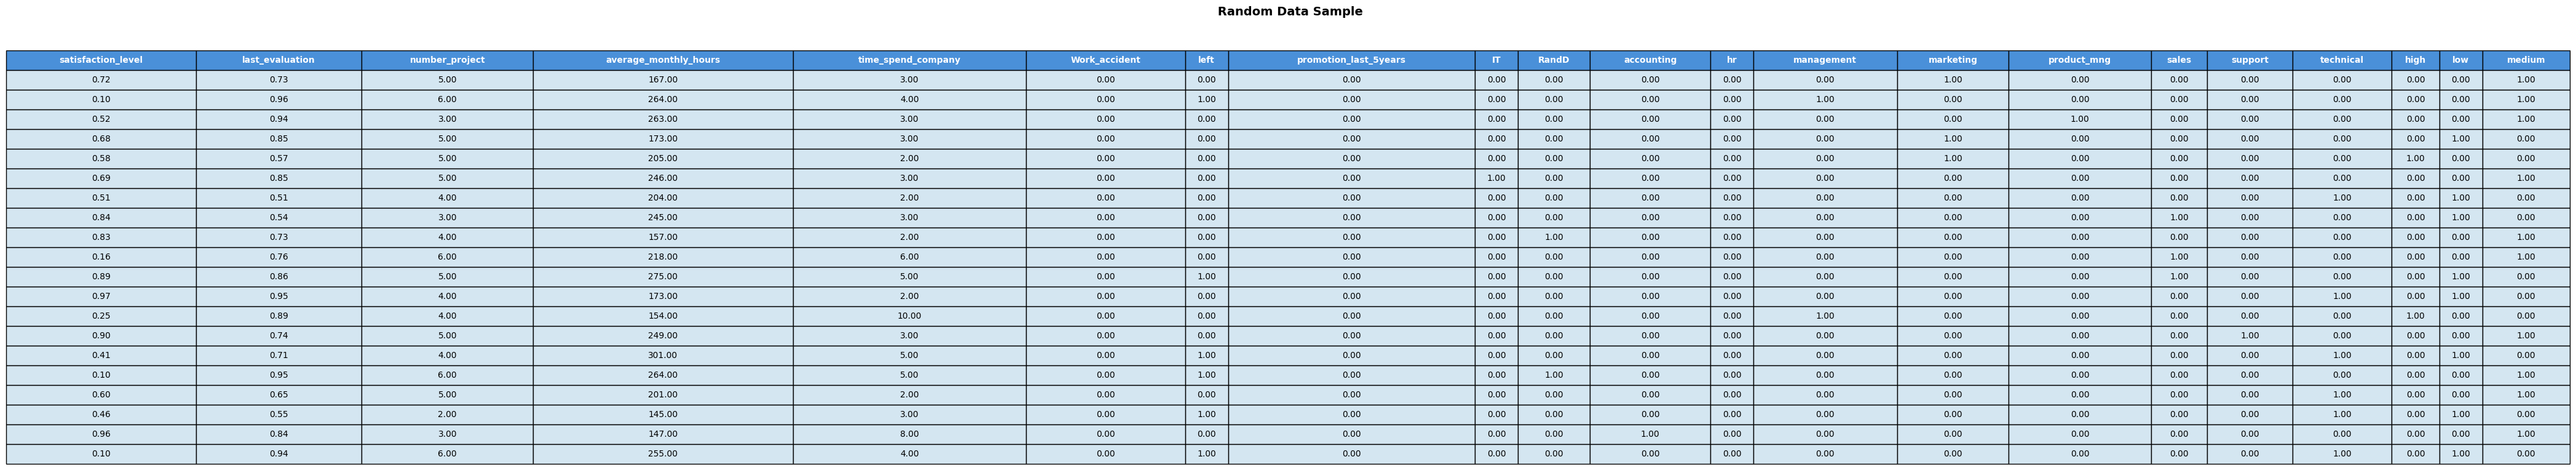

In [ ]:
# Restore dataframe to state before one-hot-encoding
#
# # In a real world, I should have used either the get_dummies() or one_hot_encoding() technique 
# earlier in Data Wrangling.
# Since it is a requirement for the assignment to use get_dummies(), I will do that here.
# To do so I'm going to restore the dataframe, apply get_dummies() and do data conversion again here
df_employeeTurnOver = df_employeeTurnOverSaved.copy(deep=True)

departments = df_employeeTurnOver['department'].str.get_dummies()
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_employeeTurnOver['department'].str.get_dummies()], axis=1)
df_employeeTurnOver.drop('department', axis=1, inplace=True)

salaryLevels = df_employeeTurnOver['salary'].str.get_dummies()
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_employeeTurnOver['salary'].str.get_dummies()], axis=1)
df_employeeTurnOver.drop('salary', axis=1, inplace=True)

# Update types dataframe to remove hardwired prefixes
df_types['Column'] = df_types['Column'].str.replace('department_', '').str.replace('salary_', '')
DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)

# Examine dataframe changes
PerformDataConversion(df_employeeTurnOver, remove_class_prefix=True)

#PrintDataFrameStatistics(df_employeeTurnOver, display_table=True)




##### **Use SMOTE Technique to Handle Class Imbalances** #####
SMOTE - Synthetic Minority Over-sampling Technique